In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

%matplotlib inline

In [42]:
df_casas = pd.read_csv(
    "../data/2023-03-08 Precios Casas RM.csv",
    encoding="latin1",
    sep=";"
)

df_propiedades = pd.read_csv(
    "../data/2023-07-18 Propiedades Web Scrape.csv",
    encoding="latin1",
    sep=None,
    engine="python"
)

print("Precios Casas RM:", df_casas.shape)
print("Propiedades Web Scrape:", df_propiedades.shape)

Precios Casas RM: (7779, 12)
Propiedades Web Scrape: (9291, 12)


In [27]:
datasets = {
    "Precios Casas RM": df_casas,
    "Propiedades Web Scrape": df_propiedades
}

for nombre, df in datasets.items():
    print("=" * 60)
    print(nombre)
    print("=" * 60)

    print(f"\nDimensiones: {df.shape}")

    print("\nTipos de datos:")
    print(df.dtypes)

    print("\nValores faltantes:")
    faltantes = df.isna().sum()
    porcentaje = (faltantes / len(df) * 100).round(2)

    resultado_faltantes = pd.DataFrame({
        "Cantidad": faltantes,
        "Porcentaje": porcentaje
    })

    display(resultado_faltantes)

    print("\nFilas duplicadas:", df.duplicated().sum())

Precios Casas RM

Dimensiones: (7779, 12)

Tipos de datos:
Price_CLP       int64
Price_UF        int64
Price_USD       int64
Comuna            str
Ubicacion         str
Dorms           int64
Baths         float64
Built Area    float64
Total Area    float64
Parking       float64
id              int64
Realtor           str
dtype: object

Valores faltantes:


,Cantidad,Porcentaje
Price_CLP,0,0.00
Price_UF,0,0.00
Price_USD,0,0.00
Comuna,0,0.00
Ubicacion,0,0.00
Dorms,0,0.00
Baths,65,0.84
Built Area,246,3.16
Total Area,208,2.67
Parking,2290,29.44



Filas duplicadas: 1
Propiedades Web Scrape

Dimensiones: (9291, 12)

Tipos de datos:
Price_CLP       int64
Price_UF      float64
Price_USD     float64
Comuna            str
Ubicacion         str
Dorms         float64
Baths         float64
Built Area    float64
Total Area    float64
Parking       float64
id            float64
Realtor           str
dtype: object

Valores faltantes:


,Cantidad,Porcentaje
Price_CLP,0,0.00
Price_UF,0,0.00
Price_USD,0,0.00
Comuna,0,0.00
Ubicacion,0,0.00
Dorms,90,0.97
Baths,154,1.66
Built Area,279,3.00
Total Area,235,2.53
Parking,2921,31.44



Filas duplicadas: 0


In [28]:
for nombre, df in datasets.items():
    print("=" * 60)
    print(nombre)
    print("=" * 60)

    columnas_numericas = [
        "Price_CLP",
        "Price_UF",
        "Price_USD",
        "Dorms",
        "Baths",
        "Built Area",
        "Total Area",
        "Parking"
    ]

    display(df[columnas_numericas].describe().T)

Precios Casas RM


,count,mean,std,min,25%,50%,75%,max
Price_CLP,7779.0,3.642481e+08,3.868810e+08,2085.0,120000000.0,205000000.0,491142000.0,5.516450e+09
Price_UF,7779.0,1.023457e+04,1.087049e+04,0.0,3372.0,5760.0,13800.0,1.550000e+05
Price_USD,7779.0,4.536091e+05,4.817945e+05,3.0,149440.0,255293.0,611634.0,6.869801e+06
Dorms,7779.0,3.994087e+00,1.622821e+00,1.0,3.0,4.0,5.0,2.700000e+01
Baths,7714.0,2.653746e+00,1.465103e+00,1.0,2.0,2.0,3.0,2.900000e+01
Built Area,7533.0,2.299237e+02,1.676899e+03,1.0,85.0,128.0,200.0,1.200000e+05
Total Area,7571.0,8.079198e+02,9.050893e+03,1.0,129.5,210.0,443.0,6.780000e+05
Parking,5489.0,2.980506e+00,1.774938e+01,1.0,1.0,2.0,3.0,1.269000e+03


Propiedades Web Scrape


,count,mean,std,min,25%,50%,75%,max
Price_CLP,9291.0,3.925134e+08,4.036515e+08,37000000.0,128206726.5,234513500.0,526753400.0,4.870665e+09
Price_UF,9291.0,1.087928e+04,1.118799e+04,1026.0,3553.5,6500.0,14600.0,1.350000e+05
Price_USD,9291.0,4.786749e+05,4.922579e+05,45122.0,156350.0,285992.0,642382.0,5.939835e+06
Dorms,9201.0,4.027062e+00,1.661530e+00,1.0,3.0,4.0,5.0,3.500000e+01
Baths,9137.0,2.749699e+00,1.478708e+00,1.0,2.0,3.0,3.0,2.900000e+01
Built Area,9012.0,6.092266e+03,5.274659e+05,1.0,90.0,131.0,209.0,5.000000e+07
Total Area,9056.0,8.910510e+02,1.129202e+04,1.0,134.0,230.0,480.0,7.200000e+05
Parking,6370.0,2.682732e+00,2.221302e+00,1.0,1.0,2.0,3.0,2.600000e+01


In [29]:
# Valores potencialmente anómalos
for nombre, df in datasets.items():
    print("=" * 60)
    print(nombre)
    print("=" * 60)

    sospechosos = df[
        (df["Price_CLP"] < 10_000_000) |
        (df["Price_UF"] <= 0) |
        (df["Built Area"] > 10_000) |
        (df["Total Area"] > 100_000) |
        (df["Parking"] > 10) |
        (df["Dorms"] > 10) |
        (df["Baths"] > 10)
    ]

    print(f"Registros sospechosos: {len(sospechosos)}")

    display(
        sospechosos[
            [
                "Price_CLP",
                "Price_UF",
                "Price_USD",
                "Comuna",
                "Ubicacion",
                "Dorms",
                "Baths",
                "Built Area",
                "Total Area",
                "Parking",
                "id",
                "Realtor"
            ]
        ].sort_values("Price_CLP")
    )

Precios Casas RM
Registros sospechosos: 168


,Price_CLP,Price_UF,Price_USD,Comuna,Ubicacion,Dorms,Baths,Built Area,Total Area,Parking,id,Realtor
7200,2085,0,3,Talagante,FranciscoMandiola104,2,1.0,80.0,160.0,2.0,11362599,NaN
4479,3171,0,4,MaipÃº,BernardoVer55,3,1.0,60.0,60.0,1.0,11572691,NaN
7359,3490,0,4,MaipÃº,Mataquito2239,5,1.0,56.0,128.0,3.0,9938202,NaN
5014,4100,0,5,MaipÃº,AsunciÃ³n2169,4,3.0,107.0,145.0,3.0,11145488,Maison & Corredores de propiedades
7383,4350,0,5,PuenteAlto,ElBalaustro,3,2.0,74.0,190.0,2.0,11013051,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
6631,2313350000,65000,2880884,Vitacura,Locurro,5,5.0,700.0,5000.0,20.0,6086253,Sucursal Cantagallo
886,2669250000,75000,3324097,Vitacura,Santamaria,4,3.0,1355.0,4047.0,12.0,12161754,Viel la Dehesa SPA
975,3131920000,88000,3900274,LasCondes,CaminoLaPosada,7,5.0,1477.0,4443.0,20.0,12136820,AgustÃ­n Fuenzalida Propiedades
860,3381050000,95000,4210523,Colina,Avda.Chicureo,6,8.0,1046.0,4820.0,16.0,12183104,AgustÃ­n Fuenzalida Propiedades


Propiedades Web Scrape
Registros sospechosos: 157


,Price_CLP,Price_UF,Price_USD,Comuna,Ubicacion,Dorms,Baths,Built Area,Total Area,Parking,id,Realtor
3329,78000000,2162.0,95122.0,Colina,Colina,11.0,4.0,184.0,184.0,3.0,9690461.0,Agente Propiedades
4397,85000000,2356.0,103659.0,LaFlorida,SeVendeLindaCasaenSanJosÃ©deLaEstrellaconAv.Uno,3.0,1.0,83.0,78.0,12.0,17143195.0,Easyprop
2611,90000000,2495.0,109756.0,Renca,CampaÃ±adeTacna1595,3.0,2.0,100350.0,80980.0,1.0,12831103.0,NaN
5714,105000000,2910.0,128049.0,Renca,Condell,11.0,5.0,232.0,220.0,3.0,15109864.0,Unne
1431,115000000,3187.0,140244.0,Independencia,Independencia,3.0,1.0,6400.0,184000.0,1.0,19551919.0,Agente Propiedades
...,...,...,...,...,...,...,...,...,...,...,...,...
7510,2705925000,75000.0,3299909.0,Vitacura,Santamaria,4.0,3.0,1355.0,4047.0,12.0,12161754.0,Viel la Dehesa SPA
7560,3174952000,88000.0,3871893.0,LasCondes,CaminoLaPosada,7.0,5.0,1477.0,4443.0,20.0,12136820.0,AgustÃ­n Fuenzalida Propiedades
7500,3427505000,95000.0,4179884.0,Colina,Avda.Chicureo,6.0,8.0,1046.0,4820.0,16.0,12183104.0,AgustÃ­n Fuenzalida Propiedades
1740,3571821000,99000.0,4355879.0,SanBernardo,SanBernardo,NaN,NaN,33000.0,33000.0,NaN,19343752.0,Corredores Asociados


In [30]:
for nombre, df in datasets.items():
    print("=" * 60)
    print(nombre)
    print("=" * 60)

    # Relación aproximada entre las distintas unidades de precio
    df_temp = df[["Price_CLP", "Price_UF", "Price_USD"]].copy()

    df_temp["CLP_por_UF"] = (
        df_temp["Price_CLP"] / df_temp["Price_UF"].replace(0, np.nan)
    )

    df_temp["CLP_por_USD"] = (
        df_temp["Price_CLP"] / df_temp["Price_USD"].replace(0, np.nan)
    )

    print("\nMediana de CLP por UF:")
    print(df_temp["CLP_por_UF"].median())

    print("\nMediana de CLP por USD:")
    print(df_temp["CLP_por_USD"].median())

    print("\nEjemplos de registros con valores extremos de CLP/UF:")
    display(
        df_temp.sort_values("CLP_por_UF").head(5)
    )

    display(
        df_temp.sort_values("CLP_por_UF", ascending=False).head(5)
    )

Precios Casas RM

Mediana de CLP por UF:
35590.0

Mediana de CLP por USD:
803.0000080300001

Ejemplos de registros con valores extremos de CLP/UF:


,Price_CLP,Price_UF,Price_USD,CLP_por_UF,CLP_por_USD
7757,18900,1,24,18900.000000,787.500000
4455,1450000,41,1806,35365.853659,802.879291
4162,37000000,1040,46077,35576.923077,803.003668
7406,37000000,1040,46077,35576.923077,803.003668
6174,47000000,1321,58531,35579.106737,802.993286


,Price_CLP,Price_UF,Price_USD,CLP_por_UF,CLP_por_USD
1570,5427000,152,6758,35703.947368,803.048239
1938,5427000,152,6758,35703.947368,803.048239
7561,15000000,421,18680,35629.453682,802.997859
2460,14500000,407,18057,35626.535627,803.012682
2665,35000000,983,43587,35605.289929,802.991718


Propiedades Web Scrape

Mediana de CLP por UF:
36079.0

Mediana de CLP por USD:
819.999983707597

Ejemplos de registros con valores extremos de CLP/UF:


,Price_CLP,Price_UF,Price_USD,CLP_por_UF,CLP_por_USD
4144,37000000,1026.0,45122.0,36062.378168,819.999114
4678,47500000,1317.0,57927.0,36066.818527,819.997583
2229,40000000,1109.0,48780.0,36068.530207,820.008200
1855,40000000,1109.0,48780.0,36068.530207,820.008200
3255,40000000,1109.0,48780.0,36068.530207,820.008200


,Price_CLP,Price_UF,Price_USD,CLP_por_UF,CLP_por_USD
4156,48000000,1330.0,58537.0,36090.225564,819.994192
8633,48000000,1330.0,58537.0,36090.225564,819.994192
502,48000000,1330.0,58537.0,36090.225564,819.994192
454,48000000,1330.0,58537.0,36090.225564,819.994192
2155,48000000,1330.0,58537.0,36090.225564,819.994192


In [31]:
df = df_casas.copy()

ratio_clp_uf = (
    df["Price_CLP"] / df["Price_UF"].replace(0, np.nan)
)

inconsistentes = df[
    ~ratio_clp_uf.between(30_000, 40_000)
].copy()

print(
    inconsistentes[
        [
            "Price_CLP",
            "Price_UF",
            "Price_USD",
            "Comuna",
            "Ubicacion",
            "id"
        ]
    ].to_string(index=True)
)

      Price_CLP  Price_UF  Price_USD       Comuna                                   Ubicacion        id
112        4520         0          6     Santiago                     CostaneraFerreaPoniente  11399089
122       11057         0         14  Providencia        MiguelClaroconSantaIsabelProvidencia  10929361
2398       7990         0         10     Pudahuel                            Callenuevaunosur   8804600
4479       3171         0          4       MaipÃº                               BernardoVer55  11572691
4902       8400         0         10     Santiago  AvenidaQuebradadeMacul&AvenidaConsistorial  11550593
5014       4100         0          5       MaipÃº                               AsunciÃ³n2169  11145488
7196       5836         0          7    LaFlorida                        BacteriolÃ³gico10883  10112287
7200       2085         0          3    Talagante                        FranciscoMandiola104  11362599
7273      10990         0         14       Colina               

In [32]:
df = df_casas.copy()

print("Price_UF = 0:", (df["Price_UF"] <= 0).sum())
print("Price_UF faltante:", df["Price_UF"].isna().sum())
print("Price_UF mínimo:", df["Price_UF"].min())
print("Price_UF máximo:", df["Price_UF"].max())

print("\nValores extremos de Price_UF:")
display(
    df[
        ["Price_UF", "Price_CLP", "Price_USD", "Comuna", "Ubicacion", "id"]
    ]
    .sort_values("Price_UF")
    .head(10)
)

display(
    df[
        ["Price_UF", "Price_CLP", "Price_USD", "Comuna", "Ubicacion", "id"]
    ]
    .sort_values("Price_UF", ascending=False)
    .head(10)
)

Price_UF = 0: 18
Price_UF faltante: 0
Price_UF mínimo: 0
Price_UF máximo: 155000

Valores extremos de Price_UF:


,Price_UF,Price_CLP,Price_USD,Comuna,Ubicacion,id
7597,0,8286,10,PuenteAlto,HaciendaelPeÃ±Ã³n,10531204
122,0,11057,14,Providencia,MiguelClaroconSantaIsabelProvidencia,10929361
112,0,4520,6,Santiago,CostaneraFerreaPoniente,11399089
7758,0,9900,12,Santiago,Rafaelsanzio-LasCondes,7754401
7427,0,4800,6,PuenteAlto,Av.EjÃ©rcitoLibertador,10931205
7423,0,8450,11,PeÃ±alolÃ©n,Penalolen,9755276
2398,0,7990,10,Pudahuel,Callenuevaunosur,8804600
4479,0,3171,4,MaipÃº,BernardoVer55,11572691
7196,0,5836,7,LaFlorida,BacteriolÃ³gico10883,10112287
7200,0,2085,3,Talagante,FranciscoMandiola104,11362599


,Price_UF,Price_CLP,Price_USD,Comuna,Ubicacion,id
2708,155000,5516450000,6869801,LasCondes,Isabellacatilca,11679296
403,135000,4804650000,5983375,LasCondes,Piedraroja,12288391
7776,105000,3736950000,4653736,LasCondes,CaminoLasFlores/CaminoPiedraRoja,6032811
6568,99980,3558288200,4431243,LasCondes,CaminoLasFlores/CaminoPiedraRoja,6233842
408,97000,3452230000,4299166,LoBarnechea,Elrodeo-avenidaladehesa,12288093
860,95000,3381050000,4210523,Colina,Avda.Chicureo,12183104
6665,90000,3203100000,3988917,LasCondes,CercanoaMallSport,5669935
4651,90000,3203100000,3988917,Vitacura,Noespecifica,11227584
975,88000,3131920000,3900274,LasCondes,CaminoLaPosada,12136820
976,80000,2847200000,3545704,Vitacura,viablanca,12136784


In [33]:
df = df_casas.copy()

indices_uf_cero = df.index[df["Price_UF"] <= 0]

print("Cantidad de registros con Price_UF <= 0:", len(indices_uf_cero))
print()

for indice in indices_uf_cero:
    fila = df.loc[indice]

    print(f"ÍNDICE: {indice}")
    print(f"  Price_CLP  = {fila['Price_CLP']}")
    print(f"  Price_UF   = {fila['Price_UF']}")
    print(f"  Price_USD  = {fila['Price_USD']}")
    print(f"  Comuna     = {fila['Comuna']}")
    print(f"  Ubicacion  = {fila['Ubicacion']}")
    print(f"  id         = {fila['id']}")
    print("-" * 50)

Cantidad de registros con Price_UF <= 0: 18

ÍNDICE: 112
  Price_CLP  = 4520
  Price_UF   = 0
  Price_USD  = 6
  Comuna     = Santiago
  Ubicacion  = CostaneraFerreaPoniente
  id         = 11399089
--------------------------------------------------
ÍNDICE: 122
  Price_CLP  = 11057
  Price_UF   = 0
  Price_USD  = 14
  Comuna     = Providencia
  Ubicacion  = MiguelClaroconSantaIsabelProvidencia
  id         = 10929361
--------------------------------------------------
ÍNDICE: 2398
  Price_CLP  = 7990
  Price_UF   = 0
  Price_USD  = 10
  Comuna     = Pudahuel
  Ubicacion  = Callenuevaunosur
  id         = 8804600
--------------------------------------------------
ÍNDICE: 4479
  Price_CLP  = 3171
  Price_UF   = 0
  Price_USD  = 4
  Comuna     = MaipÃº
  Ubicacion  = BernardoVer55
  id         = 11572691
--------------------------------------------------
ÍNDICE: 4902
  Price_CLP  = 8400
  Price_UF   = 0
  Price_USD  = 10
  Comuna     = Santiago
  Ubicacion  = AvenidaQuebradadeMacul&AvenidaC

In [34]:
df = df_casas.copy()

print("Percentiles de Price_UF:")
print(
    df["Price_UF"].quantile(
        [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    )
)

print("\nRegistros con Price_UF >= 50.000:")
extremos = df[df["Price_UF"] >= 50_000]

print("Cantidad:", len(extremos))

for indice, fila in extremos.iterrows():
    print(f"\nÍNDICE: {indice}")
    print(f"  Price_UF   = {fila['Price_UF']}")
    print(f"  Price_CLP  = {fila['Price_CLP']}")
    print(f"  Price_USD  = {fila['Price_USD']}")
    print(f"  Comuna     = {fila['Comuna']}")
    print(f"  Ubicacion  = {fila['Ubicacion']}")
    print(f"  Built Area = {fila['Built Area']}")
    print(f"  Total Area = {fila['Total Area']}")
    print(f"  Dorms      = {fila['Dorms']}")
    print(f"  Baths      = {fila['Baths']}")
    print(f"  Parking    = {fila['Parking']}")
    print(f"  id         = {fila['id']}")

Percentiles de Price_UF:
0.01     1321.0
0.05     1826.0
0.25     3372.0
0.50     5760.0
0.75    13800.0
0.95    30910.0
0.99    50000.0
Name: Price_UF, dtype: float64

Registros con Price_UF >= 50.000:
Cantidad: 82

ÍNDICE: 326
  Price_UF   = 52000
  Price_CLP  = 1850680000
  Price_USD  = 2304707
  Comuna     = LoBarnechea
  Ubicacion  = Avdaladehesa/camposdegolfladehesappw
  Built Area = 450.0
  Total Area = 2800.0
  Dorms      = 6
  Baths      = 6.0
  Parking    = 11.0
  id         = 12309007

ÍNDICE: 329
  Price_UF   = 59000
  Price_CLP  = 2099810000
  Price_USD  = 2614956
  Comuna     = LasCondes
  Ubicacion  = Malaga/apoquindo
  Built Area = 480.0
  Total Area = 1240.0
  Dorms      = 5
  Baths      = 5.0
  Parking    = 10.0
  id         = 12307126

ÍNDICE: 330
  Price_UF   = 52500
  Price_CLP  = 1868475000
  Price_USD  = 2326868
  Comuna     = LasCondes
  Ubicacion  = LaslavÃ¡ndulasconcaminolafuente
  Built Area = 488.0
  Total Area = 2421.0
  Dorms      = 4
  Baths      = 3.0
  

In [35]:
df = df_propiedades.copy()

print("Price_UF <= 0:", (df["Price_UF"] <= 0).sum())
print("Price_UF faltante:", df["Price_UF"].isna().sum())
print("Price_UF mínimo:", df["Price_UF"].min())
print("Price_UF máximo:", df["Price_UF"].max())

print("\nPercentiles de Price_UF:")
print(
    df["Price_UF"].quantile(
        [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    )
)

Price_UF <= 0: 0
Price_UF faltante: 0
Price_UF mínimo: 1026.0
Price_UF máximo: 135000.0

Percentiles de Price_UF:
0.01     1469.0
0.05     1940.0
0.25     3553.5
0.50     6500.0
0.75    14600.0
0.95    32000.0
0.99    52000.0
Name: Price_UF, dtype: float64


In [36]:
df = df_casas.copy()

# Registros donde Price_UF es válido
validos = df[df["Price_UF"] > 0].copy()

# Conversión observada
validos["CLP_por_UF"] = (
    validos["Price_CLP"] / validos["Price_UF"]
)

print("Registros con Price_UF válido:", len(validos))

print("\nMediana CLP por UF:")
print(validos["CLP_por_UF"].median())

print("\nPromedio CLP por UF:")
print(validos["CLP_por_UF"].mean())

print("\nPercentiles de CLP por UF:")
print(
    validos["CLP_por_UF"].quantile(
        [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    )
)

Registros con Price_UF válido: 7761

Mediana CLP por UF:
35590.0

Promedio CLP por UF:
35587.80307087234

Percentiles de CLP por UF:
0.01    35582.822086
0.05    35587.186833
0.25    35590.000000
0.50    35590.000000
0.75    35590.000000
0.95    35594.639866
0.99    35598.705502
Name: CLP_por_UF, dtype: float64


In [37]:
for nombre, df in datasets.items():
    print("=" * 60)
    print(nombre)
    print("=" * 60)

    print("IDs faltantes:", df["id"].isna().sum())
    print("IDs duplicados:", df["id"].duplicated().sum())
    print("IDs únicos:", df["id"].nunique())

Precios Casas RM
IDs faltantes: 0
IDs duplicados: 1
IDs únicos: 7778
Propiedades Web Scrape
IDs faltantes: 1
IDs duplicados: 0
IDs únicos: 9290


In [38]:
for nombre, df in datasets.items():
    print("=" * 60)
    print(nombre)
    print("=" * 60)

    if df["id"].duplicated().any():
        print("\nIDs duplicados:")
        print(
            df.loc[df["id"].duplicated(keep=False), ["id", "Price_UF", "Comuna", "Ubicacion"]]
            .sort_values("id")
            .to_string(index=True)
        )

    if df["id"].isna().any():
        print("\nRegistros con ID faltante:")
        print(
            df.loc[df["id"].isna(), ["id", "Price_UF", "Comuna", "Ubicacion"]]
            .to_string(index=True)
        )

Precios Casas RM

IDs duplicados:
            id  Price_UF  Comuna                            Ubicacion
5583  10215663      7500  Tiltil  Sevendecasaconampliaparcelaentiltil
5584  10215663      7500  Tiltil  Sevendecasaconampliaparcelaentiltil
Propiedades Web Scrape

Registros con ID faltante:
     id  Price_UF     Comuna  Ubicacion
976 NaN   10900.0  LasCondes  Remodelar


In [39]:
for nombre, df in datasets.items():
    print("=" * 60)
    print(nombre)
    print("=" * 60)

    print("\nEjemplos de comunas:")
    print(df["Comuna"].drop_duplicates().head(20).to_list())

    print("\nEjemplos de ubicaciones:")
    print(df["Ubicacion"].drop_duplicates().head(10).to_list())

Precios Casas RM

Ejemplos de comunas:
['QuintaNormal', 'PedroAguirreCerda', 'EstaciÃ³nCentral', 'Colina', 'LaFlorida', 'MaipÃº', 'SanBernardo', 'Santiago', 'PuenteAlto', 'LasCondes', 'Lampa', 'Quilicura', 'LaPintana', 'Renca', 'Huechuraba', 'SanMiguel', 'Ã\x91uÃ±oa', 'LaGranja', 'Pudahuel', 'Independencia']

Ejemplos de ubicaciones:
['Hoevel4548y4558', 'Rucalhue', 'AvenidaLasParcelas', 'PasajeGonzaloRojas', 'HernÃ¡nDÃ\xadazArrieta2820', 'Avenida5deAbril', 'GabrielaMistral/PabloNeruda', 'SanCristÃ³balTres', 'PasajeJosÃ©deMoraleda', 'MatÃ\xadas']
Propiedades Web Scrape

Ejemplos de comunas:
['Lampa', 'Buin', 'PuenteAlto', 'QuintaNormal', 'PeÃ±aflor', 'SanJoaquÃ\xadn', 'MaipÃº', 'Independencia', 'SanMiguel', 'Pudahuel', 'Santiago', 'SanBernardo', 'LaFlorida', 'PeÃ±alolÃ©n', 'IsladeMaipo', 'LasCondes', 'Quilicura', 'LoPrado', 'Colina', 'LaGranja']

Ejemplos de ubicaciones:
['AvenidaLaHacienda', 'Villaseca', 'BarrioAustria', 'ComercianteArmandoPÃ©rezCarrasco', 'Hostos', 'PasajeReinaldoEsco

In [40]:
ejemplos = [
    "MaipÃº",
    "PeÃ±aflor",
    "EstaciÃ³nCentral",
    "Ã\x91uÃ±oa",
    "HernÃ¡nDÃ\xadazArrieta2820"
]

for texto in ejemplos:
    try:
        corregido = texto.encode("latin1").decode("utf-8")
        print(f"{texto}  →  {corregido}")
    except UnicodeError as e:
        print(f"{texto}  → ERROR: {e}")

MaipÃº  →  Maipú
PeÃ±aflor  →  Peñaflor
EstaciÃ³nCentral  →  EstaciónCentral
ÃuÃ±oa  →  Ñuñoa
HernÃ¡nDÃ­azArrieta2820  →  HernánDíazArrieta2820


In [43]:
def corregir_encoding(texto):
    if not isinstance(texto, str):
        return texto

    try:
        return texto.encode("latin1").decode("utf-8")
    except (UnicodeEncodeError, UnicodeDecodeError):
        return texto


columnas_texto = ["Comuna", "Ubicacion", "Realtor"]

for df in datasets.values():
    for columna in columnas_texto:
        df[columna] = df[columna].apply(corregir_encoding)

print("Encoding corregido de forma segura.")

Encoding corregido de forma segura.


In [44]:
for nombre, df in datasets.items():
    print("=" * 60)
    print(nombre)
    print("=" * 60)

    print("\nEjemplos de comunas:")
    print(df["Comuna"].drop_duplicates().head(20).to_list())

    print("\nEjemplos de ubicaciones:")
    print(df["Ubicacion"].drop_duplicates().head(10).to_list())

Precios Casas RM

Ejemplos de comunas:
['QuintaNormal', 'PedroAguirreCerda', 'EstaciónCentral', 'Colina', 'LaFlorida', 'Maipú', 'SanBernardo', 'Santiago', 'PuenteAlto', 'LasCondes', 'Lampa', 'Quilicura', 'LaPintana', 'Renca', 'Huechuraba', 'SanMiguel', 'Ñuñoa', 'LaGranja', 'Pudahuel', 'Independencia']

Ejemplos de ubicaciones:
['Hoevel4548y4558', 'Rucalhue', 'AvenidaLasParcelas', 'PasajeGonzaloRojas', 'HernánDíazArrieta2820', 'Avenida5deAbril', 'GabrielaMistral/PabloNeruda', 'SanCristóbalTres', 'PasajeJosédeMoraleda', 'Matías']
Propiedades Web Scrape

Ejemplos de comunas:
['Lampa', 'Buin', 'PuenteAlto', 'QuintaNormal', 'Peñaflor', 'SanJoaquín', 'Maipú', 'Independencia', 'SanMiguel', 'Pudahuel', 'Santiago', 'SanBernardo', 'LaFlorida', 'Peñalolén', 'IsladeMaipo', 'LasCondes', 'Quilicura', 'LoPrado', 'Colina', 'LaGranja']

Ejemplos de ubicaciones:
['AvenidaLaHacienda', 'Villaseca', 'BarrioAustria', 'ComercianteArmandoPérezCarrasco', 'Hostos', 'PasajeReinaldoEscobar', 'CalleCardenalFresno'

In [45]:
for nombre, df in datasets.items():
    print("=" * 60)
    print(nombre)
    print("=" * 60)

    sospechosos = df[
        (df["Built Area"] > 1000) |
        (df["Total Area"] > 5000)
    ].copy()

    print("Registros encontrados:", len(sospechosos))

    display(
        sospechosos[
            [
                "Price_UF",
                "Comuna",
                "Ubicacion",
                "Built Area",
                "Total Area",
                "Dorms",
                "Baths",
                "Parking"
            ]
        ].sort_values("Built Area", ascending=False)
    )

Precios Casas RM
Registros encontrados: 221


,Price_UF,Comuna,Ubicacion,Built Area,Total Area,Dorms,Baths,Parking
7214,3653,Santiago,Av.LosCerrillos639,120000.0,300000.0,3,1.0,2.0
784,60000,SanJosédeMaipo,Casamaipo,60000.0,60000.0,14,NaN,NaN
5874,25000,Colina,lasbrisasdechicureo,31972.0,2892.0,4,4.0,6.0
2248,26000,LoBarnechea,Caminodelabrisa,18917.0,11927.0,5,4.0,2.0
2773,25999,Talagante,LonquenSurParadero/,17525.0,1800.0,6,3.0,5.0
...,...,...,...,...,...,...,...,...
4499,7500,Paine,Chada/lasvertientes,100.0,5100.0,4,2.0,NaN
7262,4468,Independencia,BrigadierCarlosGarrido1718,99.0,160000.0,4,2.0,1.0
2027,2957,Curacaví,BosquedeLasAchiras,92.0,5138.0,1,1.0,5.0
6420,1630,SanBernardo,socompaconavenidaloblanco,36.0,11300.0,3,1.0,NaN


Propiedades Web Scrape
Registros encontrados: 254


,Price_UF,Comuna,Ubicacion,Built Area,Total Area,Dorms,Baths,Parking
1464,4300.0,Paine,18deseptiemrecohuelquem,50000000.0,5000.0,NaN,NaN,NaN
313,7150.0,Paine,Hermosaparcelaconpiscinaenpaine,2710000.0,5400.0,6.0,3.0,5.0
717,3603.0,Cerrillos,Av.LosCerrillos639,120000.0,300000.0,3.0,1.0,2.0
2611,2495.0,Renca,CampañadeTacna1595,100350.0,80980.0,3.0,2.0,1.0
2228,60000.0,SanJosédeMaipo,Casamaipo,60000.0,60000.0,14.0,NaN,NaN
...,...,...,...,...,...,...,...,...
6766,11000.0,Lampa,Condominiosantarosadelampa,117.0,5100.0,3.0,2.0,14.0
6783,7500.0,Paine,Chada/lasvertientes,100.0,5100.0,4.0,2.0,NaN
6713,6746.0,Talagante,Pasadopueblodelonquen,70.0,5700.0,NaN,1.0,NaN
2960,1608.0,SanBernardo,socompaconavenidaloblanco,36.0,11300.0,3.0,1.0,NaN


In [46]:
for nombre, df in datasets.items():
    print("=" * 60)
    print(nombre)
    print("=" * 60)

    print("\nBuilt Area:")
    print("  > 1.000 m²:", (df["Built Area"] > 1_000).sum())
    print("  > 10.000 m²:", (df["Built Area"] > 10_000).sum())
    print("  > 100.000 m²:", (df["Built Area"] > 100_000).sum())
    print("  > 1.000.000 m²:", (df["Built Area"] > 1_000_000).sum())

    print("\nTotal Area:")
    print("  > 5.000 m²:", (df["Total Area"] > 5_000).sum())
    print("  > 10.000 m²:", (df["Total Area"] > 10_000).sum())
    print("  > 100.000 m²:", (df["Total Area"] > 100_000).sum())

    print("\nBuilt Area > Total Area:")
    print(
        (
            (df["Built Area"].notna()) &
            (df["Total Area"].notna()) &
            (df["Built Area"] > df["Total Area"])
        ).sum()
    )

Precios Casas RM

Built Area:
  > 1.000 m²: 70
  > 10.000 m²: 8
  > 100.000 m²: 1
  > 1.000.000 m²: 0

Total Area:
  > 5.000 m²: 166
  > 10.000 m²: 33
  > 100.000 m²: 3

Built Area > Total Area:
477
Propiedades Web Scrape

Built Area:
  > 1.000 m²: 79
  > 10.000 m²: 14
  > 100.000 m²: 4
  > 1.000.000 m²: 2

Total Area:
  > 5.000 m²: 197
  > 10.000 m²: 43
  > 100.000 m²: 4

Built Area > Total Area:
516


In [47]:
for nombre, df in datasets.items():
    print("=" * 60)
    print(nombre)
    print("=" * 60)

    areas = df[
        (df["Built Area"] > 0) &
        (df["Total Area"] > 0)
    ].copy()

    areas["ratio_construido"] = (
        areas["Built Area"] / areas["Total Area"]
    )

    print("\nPercentiles de Built Area / Total Area:")
    print(
        areas["ratio_construido"].quantile(
            [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
        )
    )

    print("\nRatio > 1:", (areas["ratio_construido"] > 1).sum())
    print("Ratio > 2:", (areas["ratio_construido"] > 2).sum())
    print("Ratio > 10:", (areas["ratio_construido"] > 10).sum())
    print("Ratio > 100:", (areas["ratio_construido"] > 100).sum())

Precios Casas RM

Percentiles de Built Area / Total Area:
0.01    0.039356
0.05    0.134641
0.25    0.385906
0.50    0.561404
0.75    0.800000
0.95    1.105465
0.99    2.028394
Name: ratio_construido, dtype: float64

Ratio > 1: 477
Ratio > 2: 76
Ratio > 10: 14
Ratio > 100: 2
Propiedades Web Scrape

Percentiles de Built Area / Total Area:
0.01    0.037312
0.05    0.135012
0.25    0.375000
0.50    0.545848
0.75    0.777778
0.95    1.064103
0.99    1.992696
Name: ratio_construido, dtype: float64

Ratio > 1: 516
Ratio > 2: 81
Ratio > 10: 16
Ratio > 100: 5


In [48]:
for nombre, df in datasets.items():
    print("=" * 60)
    print(nombre)
    print("=" * 60)

    areas = df[
        (df["Built Area"] > 0) &
        (df["Total Area"] > 0)
    ].copy()

    areas["ratio_construido"] = (
        areas["Built Area"] / areas["Total Area"]
    )

    extremos = areas[
        areas["ratio_construido"] > 10
    ].sort_values("ratio_construido", ascending=False)

    print("Registros:", len(extremos))

    display(
        extremos[
            [
                "Price_UF",
                "Comuna",
                "Ubicacion",
                "Built Area",
                "Total Area",
                "ratio_construido",
                "Dorms",
                "Baths",
                "Parking"
            ]
        ]
    )

Precios Casas RM
Registros: 14


,Price_UF,Comuna,Ubicacion,Built Area,Total Area,ratio_construido,Dorms,Baths,Parking
3470,4355,Maipú,villaoneillexfuncionariosgoodyear,190.0,1.0,190.000000,4,2.0,4.0
2648,39900,Vitacura,LuisCarrera/LuisPasteur,168.0,1.0,168.000000,3,2.0,NaN
1902,2810,Pudahuel,PasajeCeti8642estrellasurPudahuel,6388.0,70.0,91.257143,2,1.0,1.0
385,14535,Vitacura,ColegioSagradosCorazonesdeManquehue,15951.0,250.0,63.804000,5,1.0,3.0
3131,11950,Peñaflor,CondominioSantaMaríadePeñaflor,8000.0,320.0,25.000000,5,4.0,NaN
3690,11999,Talagante,Balmaceda,5042.0,230.0,21.921739,4,2.0,3.0
5951,16000,Colina,LoArcaya,5000.0,247.0,20.242915,4,4.0,7.0
3063,45999,Talagante,PlazaDeTalagante,4000.0,200.0,20.000000,6,4.0,3.0
4776,16500,Colina,Chicureo,5000.0,278.0,17.985612,5,5.0,10.0
7250,18501,LasCondes,Vaticano,167.0,10.0,16.700000,3,2.0,2.0


Propiedades Web Scrape
Registros: 16


,Price_UF,Comuna,Ubicacion,Built Area,Total Area,ratio_construido,Dorms,Baths,Parking
1464,4300.0,Paine,18deseptiemrecohuelquem,50000000.0,5000.0,10000.000000,NaN,NaN,NaN
313,7150.0,Paine,Hermosaparcelaconpiscinaenpaine,2710000.0,5400.0,501.851852,6.0,3.0,5.0
3056,11000.0,SanMiguel,¡oportunidad!!!ventaterrenozonazu-2apasosdelme...,440.0,1.0,440.000000,3.0,2.0,NaN
8156,3603.0,Maipú,villaoneillexfuncionariosgoodyear,190.0,1.0,190.000000,4.0,2.0,4.0
7123,15315.0,Ñuñoa,JoséDomingoCañas-PedrodeValdivia,31130.0,248.0,125.524194,6.0,4.0,1.0
6375,2240.0,PuenteAlto,caminointernacionalconnocedal,7381.0,80.0,92.262500,4.0,NaN,NaN
1390,1857.0,Melipilla,PadreAlbertoHurtado,5661.0,81.0,69.888889,4.0,1.0,NaN
4780,6295.0,Quilicura,Av.LoMarcoleta,13214.0,255.0,51.819608,4.0,2.0,1.0
1796,11200.0,Talagante,#¿NOMBRE?,5000.0,186.0,26.881720,4.0,3.0,1.0
8219,11999.0,Talagante,Balmaceda,5042.0,230.0,21.921739,4.0,2.0,3.0


In [49]:
for nombre, df in datasets.items():
    print("=" * 60)
    print(nombre)
    print("=" * 60)

    print("\nBuilt Area - valores más frecuentes:")
    print(
        df["Built Area"]
        .value_counts(dropna=True)
        .head(20)
    )

    print("\nTotal Area - valores más frecuentes:")
    print(
        df["Total Area"]
        .value_counts(dropna=True)
        .head(20)
    )

Precios Casas RM

Built Area - valores más frecuentes:
Built Area
140.0    274
90.0     218
100.0    203
80.0     198
120.0    192
70.0     173
110.0    126
200.0    125
180.0    125
60.0     115
160.0    107
150.0    103
75.0     102
130.0    101
65.0      84
250.0     81
85.0      77
170.0     71
300.0     70
50.0      68
Name: count, dtype: int64

Total Area - valores más frecuentes:
Total Area
200.0     215
120.0     172
100.0     152
300.0     132
5000.0    126
180.0     118
80.0      115
160.0     105
90.0      101
110.0      93
400.0      89
140.0      86
130.0      85
250.0      85
500.0      81
162.0      75
150.0      72
128.0      67
350.0      62
70.0       61
Name: count, dtype: int64
Propiedades Web Scrape

Built Area - valores más frecuentes:
Built Area
140.0    366
90.0     256
120.0    236
100.0    226
80.0     191
70.0     177
110.0    163
180.0    155
200.0    151
150.0    131
60.0     127
160.0    126
130.0    112
75.0     111
170.0    106
300.0     99
250.0     92


In [50]:
for nombre, df in datasets.items():
    print("=" * 60)
    print(nombre)
    print("=" * 60)

    print("\nBuilt Area:")
    for limite in [1000, 2000, 5000, 10000, 20000]:
        print(
            f"  > {limite:,} m²:",
            (df["Built Area"] > limite).sum()
        )

    print("\nTotal Area:")
    for limite in [5000, 10000, 20000, 50000, 100000]:
        print(
            f"  > {limite:,} m²:",
            (df["Total Area"] > limite).sum()
        )

Precios Casas RM

Built Area:
  > 1,000 m²: 70
  > 2,000 m²: 45
  > 5,000 m²: 21
  > 10,000 m²: 8
  > 20,000 m²: 3

Total Area:
  > 5,000 m²: 166
  > 10,000 m²: 33
  > 20,000 m²: 15
  > 50,000 m²: 8
  > 100,000 m²: 3
Propiedades Web Scrape

Built Area:
  > 1,000 m²: 79
  > 2,000 m²: 49
  > 5,000 m²: 27
  > 10,000 m²: 14
  > 20,000 m²: 8

Total Area:
  > 5,000 m²: 197
  > 10,000 m²: 43
  > 20,000 m²: 20
  > 50,000 m²: 10
  > 100,000 m²: 4


In [51]:
for nombre, df in datasets.items():
    print("=" * 60)
    print(nombre)
    print("=" * 60)

    casos = df[
        (df["Built Area"] > 10_000) |
        (df["Built Area"] > 100 * df["Total Area"])
    ].copy()

    casos["ratio_construido"] = (
        casos["Built Area"] / casos["Total Area"]
    )

    print("Registros:", len(casos))

    display(
        casos[
            [
                "Price_UF",
                "Comuna",
                "Ubicacion",
                "Built Area",
                "Total Area",
                "ratio_construido",
                "Dorms",
                "Baths",
                "Parking"
            ]
        ].sort_values("Built Area", ascending=False)
    )

Precios Casas RM
Registros: 10


,Price_UF,Comuna,Ubicacion,Built Area,Total Area,ratio_construido,Dorms,Baths,Parking
7214,3653,Santiago,Av.LosCerrillos639,120000.0,300000.0,0.400000,3,1.0,2.0
784,60000,SanJosédeMaipo,Casamaipo,60000.0,60000.0,1.000000,14,NaN,NaN
5874,25000,Colina,lasbrisasdechicureo,31972.0,2892.0,11.055325,4,4.0,6.0
2248,26000,LoBarnechea,Caminodelabrisa,18917.0,11927.0,1.586065,5,4.0,2.0
2773,25999,Talagante,LonquenSurParadero/,17525.0,1800.0,9.736111,6,3.0,5.0
385,14535,Vitacura,ColegioSagradosCorazonesdeManquehue,15951.0,250.0,63.804000,5,1.0,3.0
5038,24900,Santiago,TalaganteSantiagodeChile,15190.0,15190.0,1.000000,5,3.0,10.0
4688,3091,Maipú,Villalaarboleda,10875.0,10875.0,1.000000,4,2.0,1.0
3470,4355,Maipú,villaoneillexfuncionariosgoodyear,190.0,1.0,190.000000,4,2.0,4.0
2648,39900,Vitacura,LuisCarrera/LuisPasteur,168.0,1.0,168.000000,3,2.0,NaN


Propiedades Web Scrape
Registros: 16


,Price_UF,Comuna,Ubicacion,Built Area,Total Area,ratio_construido,Dorms,Baths,Parking
1464,4300.0,Paine,18deseptiemrecohuelquem,50000000.0,5000.0,10000.000000,NaN,NaN,NaN
313,7150.0,Paine,Hermosaparcelaconpiscinaenpaine,2710000.0,5400.0,501.851852,6.0,3.0,5.0
717,3603.0,Cerrillos,Av.LosCerrillos639,120000.0,300000.0,0.400000,3.0,1.0,2.0
2611,2495.0,Renca,CampañadeTacna1595,100350.0,80980.0,1.239195,3.0,2.0,1.0
2228,60000.0,SanJosédeMaipo,Casamaipo,60000.0,60000.0,1.000000,14.0,NaN,NaN
1740,99000.0,SanBernardo,SanBernardo,33000.0,33000.0,1.000000,NaN,NaN,NaN
7123,15315.0,Ñuñoa,JoséDomingoCañas-PedrodeValdivia,31130.0,248.0,125.524194,6.0,4.0,1.0
3238,20767.0,Providencia,RicardoMattePerez0210,24546.0,3546.0,6.922166,5.0,3.0,NaN
7038,4776.0,Talagante,Viniendodesdesantiagoporlonquenesantesdellegar...,19000.0,19000.0,1.000000,1.0,1.0,NaN
7725,26000.0,LoBarnechea,Caminodelabrisa,18917.0,11927.0,1.586065,5.0,4.0,2.0


In [52]:
for nombre, df in datasets.items():
    print("=" * 60)
    print(nombre)
    print("=" * 60)

    ratio = df["Built Area"] / df["Total Area"]

    eliminar = (
        (df["Built Area"] > 0) &
        (df["Total Area"] > 0) &
        (
            (ratio > 10) |
            (ratio > 100)
        )
    )

    print("Registros a excluir por superficies:", eliminar.sum())

Precios Casas RM
Registros a excluir por superficies: 14
Propiedades Web Scrape
Registros a excluir por superficies: 16


In [53]:
datasets_limpios = {}

for nombre, df in datasets.items():
    df_limpio = df.copy()

    ratio = (
        df_limpio["Built Area"] /
        df_limpio["Total Area"]
    )

    excluir_superficie = (
        (df_limpio["Built Area"] > 0) &
        (df_limpio["Total Area"] > 0) &
        (ratio > 10)
    )

    df_limpio = df_limpio[~excluir_superficie].copy()

    datasets_limpios[nombre] = df_limpio

    print("=" * 60)
    print(nombre)
    print("=" * 60)
    print("Registros originales:", len(df))
    print("Registros excluidos:", excluir_superficie.sum())
    print("Registros restantes:", len(df_limpio))

Precios Casas RM
Registros originales: 7779
Registros excluidos: 14
Registros restantes: 7765
Propiedades Web Scrape
Registros originales: 9291
Registros excluidos: 16
Registros restantes: 9275


In [54]:
for nombre, df in datasets_limpios.items():
    print("=" * 60)
    print(nombre)
    print("=" * 60)

    for columna in ["Dorms", "Baths"]:
        print(f"\n{columna}")

        print("  Faltantes:", df[columna].isna().sum())
        print("  Mínimo:", df[columna].min())
        print("  Máximo:", df[columna].max())

        print("\n  Percentiles:")
        print(
            df[columna].quantile(
                [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
            )
        )

        print("\n  Valores más frecuentes:")
        print(
            df[columna]
            .value_counts(dropna=True)
            .sort_index()
            .head(30)
        )

Precios Casas RM

Dorms
  Faltantes: 0
  Mínimo: 1
  Máximo: 27

  Percentiles:
0.01     2.0
0.05     2.0
0.25     3.0
0.50     4.0
0.75     5.0
0.95     7.0
0.99    10.0
Name: Dorms, dtype: float64

  Valores más frecuentes:
Dorms
1       55
2      631
3     2762
4     2154
5     1241
6      503
7      202
8       92
9       37
10      40
11      12
12       9
13       6
14       5
15       6
16       2
17       2
18       1
20       1
24       1
25       2
27       1
Name: count, dtype: int64

Baths
  Faltantes: 65
  Mínimo: 1.0
  Máximo: 29.0

  Percentiles:
0.01    1.0
0.05    1.0
0.25    2.0
0.50    2.0
0.75    3.0
0.95    5.0
0.99    7.0
Name: Baths, dtype: float64

  Valores más frecuentes:
Baths
1.0     1699
2.0     2285
3.0     1963
4.0     1023
5.0      459
6.0      153
7.0       75
8.0       23
9.0        7
11.0       3
12.0       3
13.0       1
15.0       4
21.0       1
29.0       1
Name: count, dtype: int64
Propiedades Web Scrape

Dorms
  Faltantes: 88
  Mínimo: 1.0
  Máxi

In [55]:
for nombre, df in datasets_limpios.items():
    print("=" * 60)
    print(nombre)
    print("=" * 60)

    print("\nParking")
    print("  Faltantes:", df["Parking"].isna().sum())
    print("  Porcentaje faltante:",
          round(df["Parking"].isna().mean() * 100, 2), "%")
    print("  Mínimo:", df["Parking"].min())
    print("  Máximo:", df["Parking"].max())

    print("\nPercentiles:")
    print(
        df["Parking"].quantile(
            [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
        )
    )

    print("\nValores más frecuentes:")
    print(
        df["Parking"]
        .value_counts(dropna=True)
        .sort_index()
        .head(40)
    )

Precios Casas RM

Parking
  Faltantes: 2288
  Porcentaje faltante: 29.47 %
  Mínimo: 1.0
  Máximo: 1269.0

Percentiles:
0.01     1.0
0.05     1.0
0.25     1.0
0.50     2.0
0.75     3.0
0.95     6.2
0.99    12.0
Name: Parking, dtype: float64

Valores más frecuentes:
Parking
1.0       1629
2.0       1907
3.0        826
4.0        445
5.0        212
6.0        184
7.0         47
8.0         84
9.0          9
10.0        52
11.0        10
12.0        18
13.0         9
14.0         9
15.0         8
16.0         2
17.0         2
18.0         2
19.0         1
20.0         9
22.0         5
23.0         2
30.0         2
60.0         1
307.0        1
1269.0       1
Name: count, dtype: int64
Propiedades Web Scrape

Parking
  Faltantes: 2917
  Porcentaje faltante: 31.45 %
  Mínimo: 1.0
  Máximo: 26.0

Percentiles:
0.01     1.0
0.05     1.0
0.25     1.0
0.50     2.0
0.75     3.0
0.95     6.0
0.99    12.0
Name: Parking, dtype: float64

Valores más frecuentes:
Parking
1.0     1845
2.0     2184
3.0   

In [56]:
for nombre, df in datasets_limpios.items():
    print("=" * 60)
    print(nombre)
    print("=" * 60)

    casos = df[df["Parking"] > 50].copy()

    print("Registros con Parking > 50:", len(casos))

    display(
        casos[
            [
                "Price_UF",
                "Comuna",
                "Ubicacion",
                "Built Area",
                "Total Area",
                "Dorms",
                "Baths",
                "Parking"
            ]
        ].sort_values("Parking", ascending=False)
    )

Precios Casas RM
Registros con Parking > 50: 3


,Price_UF,Comuna,Ubicacion,Built Area,Total Area,Dorms,Baths,Parking
253,26000,Ñuñoa,Hernancortes//pedrodevaldivia,567.0,702.0,11,4.0,1269.0
1495,5900,EstaciónCentral,GeneralVelásquez,150.0,150.0,3,2.0,307.0
5146,21650,Peñaflor,LasPalmeras,505.0,7332.0,3,5.0,60.0


Propiedades Web Scrape
Registros con Parking > 50: 0


,Price_UF,Comuna,Ubicacion,Built Area,Total Area,Dorms,Baths,Parking


In [57]:
datasets_limpios_parking = {}

for nombre, df in datasets_limpios.items():
    df_limpio = df.copy()

    excluir_parking = df_limpio["Parking"].isin([307, 1269])

    df_limpio = df_limpio[~excluir_parking].copy()

    datasets_limpios_parking[nombre] = df_limpio

    print("=" * 60)
    print(nombre)
    print("=" * 60)
    print("Registros antes:", len(df))
    print("Registros excluidos por Parking:", excluir_parking.sum())
    print("Registros después:", len(df_limpio))

Precios Casas RM
Registros antes: 7765
Registros excluidos por Parking: 2
Registros después: 7763
Propiedades Web Scrape
Registros antes: 9275
Registros excluidos por Parking: 0
Registros después: 9275


In [58]:
for nombre, df in datasets_limpios_parking.items():
    print("=" * 60)
    print(nombre)
    print("=" * 60)

    casos = df[df["Price_UF"] <= 0].copy()

    print("Registros con Price_UF <= 0:", len(casos))

    display(
        casos[
            [
                "Price_CLP",
                "Price_UF",
                "Price_USD",
                "Comuna",
                "Ubicacion",
                "Built Area",
                "Total Area",
                "Dorms",
                "Baths",
                "Parking"
            ]
        ]
    )

Precios Casas RM
Registros con Price_UF <= 0: 18


,Price_CLP,Price_UF,Price_USD,Comuna,Ubicacion,Built Area,Total Area,Dorms,Baths,Parking
112,4520,0,6,Santiago,CostaneraFerreaPoniente,82.0,140.0,4,3.0,4.0
122,11057,0,14,Providencia,MiguelClaroconSantaIsabelProvidencia,229.0,248.0,3,2.0,2.0
2398,7990,0,10,Pudahuel,Callenuevaunosur,161.0,233.0,4,3.0,2.0
4479,3171,0,4,Maipú,BernardoVer55,60.0,60.0,3,1.0,1.0
4902,8400,0,10,Santiago,AvenidaQuebradadeMacul&AvenidaConsistorial,127.0,250.0,4,3.0,2.0
5014,4100,0,5,Maipú,Asunción2169,107.0,145.0,4,3.0,3.0
7196,5836,0,7,LaFlorida,Bacteriológico10883,127.0,300.0,3,2.0,2.0
7200,2085,0,3,Talagante,FranciscoMandiola104,80.0,160.0,2,1.0,2.0
7273,10990,0,14,Colina,Fundosanjorge,220.0,5000.0,5,4.0,4.0
7359,3490,0,4,Maipú,Mataquito2239,56.0,128.0,5,1.0,3.0


Propiedades Web Scrape
Registros con Price_UF <= 0: 0


,Price_CLP,Price_UF,Price_USD,Comuna,Ubicacion,Built Area,Total Area,Dorms,Baths,Parking


In [59]:
for nombre, df in datasets_limpios_parking.items():
    print("=" * 60)
    print(nombre)
    print("=" * 60)

    duplicados = df[df.duplicated(keep=False)].copy()

    print("Registros involucrados en duplicados:", len(duplicados))

    if len(duplicados) > 0:
        display(
            duplicados[
                [
                    "Price_CLP",
                    "Price_UF",
                    "Price_USD",
                    "Comuna",
                    "Ubicacion",
                    "Dorms",
                    "Baths",
                    "Built Area",
                    "Total Area",
                    "Parking",
                    "id"
                ]
            ].sort_values("id")
        )

Precios Casas RM
Registros involucrados en duplicados: 2


,Price_CLP,Price_UF,Price_USD,Comuna,Ubicacion,Dorms,Baths,Built Area,Total Area,Parking,id
5583,266925000,7500,332410,Tiltil,Sevendecasaconampliaparcelaentiltil,4,3.0,250.0,6000.0,1.0,10215663
5584,266925000,7500,332410,Tiltil,Sevendecasaconampliaparcelaentiltil,4,3.0,250.0,6000.0,1.0,10215663


Propiedades Web Scrape
Registros involucrados en duplicados: 0


In [60]:
datasets_finales = {}

for nombre, df in datasets_limpios_parking.items():
    df_final = df.copy()

    # 1. Eliminar registros sin un precio UF válido
    df_final = df_final[
        df_final["Price_UF"] > 0
    ].copy()

    # 2. Eliminar filas completamente duplicadas
    df_final = df_final.drop_duplicates().copy()

    datasets_finales[nombre] = df_final

    print("=" * 60)
    print(nombre)
    print("=" * 60)
    print("Registros finales:", len(df_final))

Precios Casas RM
Registros finales: 7744
Propiedades Web Scrape
Registros finales: 9275


In [61]:
df_casas_final = datasets_finales["Precios Casas RM"]
df_propiedades_final = datasets_finales["Propiedades Web Scrape"]

ids_casas = set(df_casas_final["id"].dropna())
ids_propiedades = set(df_propiedades_final["id"].dropna())

ids_comunes = ids_casas & ids_propiedades

print("IDs únicos - Precios Casas RM:", len(ids_casas))
print("IDs únicos - Propiedades Web Scrape:", len(ids_propiedades))
print("IDs presentes en ambos datasets:", len(ids_comunes))

print(
    "\nPorcentaje del primer dataset que aparece en el segundo:",
    round(len(ids_comunes) / len(ids_casas) * 100, 2),
    "%"
)

print(
    "Porcentaje del segundo dataset que aparece en el primero:",
    round(len(ids_comunes) / len(ids_propiedades) * 100, 2),
    "%"
)

IDs únicos - Precios Casas RM: 7744
IDs únicos - Propiedades Web Scrape: 9274
IDs presentes en ambos datasets: 3190

Porcentaje del primer dataset que aparece en el segundo: 41.19 %
Porcentaje del segundo dataset que aparece en el primero: 34.4 %


In [62]:
df_casas_final = datasets_finales["Precios Casas RM"]
df_propiedades_final = datasets_finales["Propiedades Web Scrape"]

ids_comunes = set(
    df_casas_final["id"].dropna()
) & set(
    df_propiedades_final["id"].dropna()
)

comunes_casas = df_casas_final[
    df_casas_final["id"].isin(ids_comunes)
].copy()

comunes_propiedades = df_propiedades_final[
    df_propiedades_final["id"].isin(ids_comunes)
].copy()

print("Registros compartidos en Precios Casas RM:", len(comunes_casas))
print("Registros compartidos en Propiedades Web Scrape:", len(comunes_propiedades))

print("\nIDs duplicados dentro de cada dataset:")
print(
    "Precios Casas RM:",
    comunes_casas["id"].duplicated().sum()
)
print(
    "Propiedades Web Scrape:",
    comunes_propiedades["id"].duplicated().sum()
)

Registros compartidos en Precios Casas RM: 3190
Registros compartidos en Propiedades Web Scrape: 3190

IDs duplicados dentro de cada dataset:
Precios Casas RM: 0
Propiedades Web Scrape: 0


In [63]:
columnas_comparar = [
    "Price_UF",
    "Comuna",
    "Dorms",
    "Baths",
    "Built Area",
    "Total Area",
    "Parking"
]

comparacion = comunes_casas[
    ["id"] + columnas_comparar
].merge(
    comunes_propiedades[
        ["id"] + columnas_comparar
    ],
    on="id",
    suffixes=("_marzo", "_julio")
)

print("Registros comparados:", len(comparacion))

print("\nDiferencias de precio:")
print(
    "Precio UF igual:",
    (
        comparacion["Price_UF_marzo"]
        == comparacion["Price_UF_julio"]
    ).sum()
)

print(
    "Precio UF diferente:",
    (
        comparacion["Price_UF_marzo"]
        != comparacion["Price_UF_julio"]
    ).sum()
)

print("\nDiferencias de características:")

for columna in [
    "Comuna",
    "Dorms",
    "Baths",
    "Built Area",
    "Total Area",
    "Parking"
]:
    diferentes = (
        comparacion[f"{columna}_marzo"]
        != comparacion[f"{columna}_julio"]
    )

    # NaN != NaN produce True, por eso corregimos esos casos
    ambos_faltantes = (
        comparacion[f"{columna}_marzo"].isna()
        & comparacion[f"{columna}_julio"].isna()
    )

    diferentes = diferentes & ~ambos_faltantes

    print(
        f"{columna}:",
        diferentes.sum(),
        "diferencias"
    )

Registros comparados: 3190

Diferencias de precio:
Precio UF igual: 1474
Precio UF diferente: 1716

Diferencias de características:
Comuna: 10 diferencias
Dorms: 26 diferencias
Baths: 15 diferencias
Built Area: 34 diferencias
Total Area: 35 diferencias
Parking: 58 diferencias


In [64]:
comparacion["Cambio_UF"] = (
    comparacion["Price_UF_julio"]
    - comparacion["Price_UF_marzo"]
)

comparacion["Cambio_porcentual"] = (
    comparacion["Cambio_UF"]
    / comparacion["Price_UF_marzo"]
) * 100

print("Resumen del cambio de precio:")
display(
    comparacion[
        ["Price_UF_marzo", "Price_UF_julio",
         "Cambio_UF", "Cambio_porcentual"]
    ].describe()
)

print("\nPropiedades con aumento de precio:",
      (comparacion["Cambio_UF"] > 0).sum())

print("Propiedades con disminución de precio:",
      (comparacion["Cambio_UF"] < 0).sum())

print("Propiedades sin cambio:",
      (comparacion["Cambio_UF"] == 0).sum())

Resumen del cambio de precio:


,Price_UF_marzo,Price_UF_julio,Cambio_UF,Cambio_porcentual
count,3190.000000,3190.000000,3190.000000,3190.000000
mean,12234.642947,12060.609718,-174.033229,-0.714639
std,12778.147753,12678.055524,804.460906,58.618235
min,309.000000,1026.000000,-12800.000000,-58.248588
25%,3650.750000,3534.000000,-77.000000,-1.364408
50%,7024.000000,6929.000000,-19.000000,-0.542945
75%,16800.000000,16500.000000,0.000000,0.000000
max,135000.000000,135000.000000,12000.000000,3298.058252



Propiedades con aumento de precio: 94
Propiedades con disminución de precio: 1622
Propiedades sin cambio: 1474


In [65]:
print("Mayores aumentos porcentuales:")
display(
    comparacion[
        [
            "id",
            "Price_UF_marzo",
            "Price_UF_julio",
            "Cambio_UF",
            "Cambio_porcentual",
            "Comuna_marzo",
            "Dorms_marzo",
            "Baths_marzo",
            "Built Area_marzo",
            "Total Area_marzo"
        ]
    ]
    .sort_values("Cambio_porcentual", ascending=False)
    .head(10)
)

print("\nMayores disminuciones porcentuales:")
display(
    comparacion[
        [
            "id",
            "Price_UF_marzo",
            "Price_UF_julio",
            "Cambio_UF",
            "Cambio_porcentual",
            "Comuna_marzo",
            "Dorms_marzo",
            "Baths_marzo",
            "Built Area_marzo",
            "Total Area_marzo"
        ]
    ]
    .sort_values("Cambio_porcentual")
    .head(10)
)

print("\nMayores cambios absolutos:")
display(
    comparacion[
        [
            "id",
            "Price_UF_marzo",
            "Price_UF_julio",
            "Cambio_UF",
            "Cambio_porcentual",
            "Comuna_marzo"
        ]
    ]
    .sort_values("Cambio_UF", key=lambda x: x.abs(), ascending=False)
    .head(10)
)

Mayores aumentos porcentuales:


,id,Price_UF_marzo,Price_UF_julio,Cambio_UF,Cambio_porcentual,Comuna_marzo,Dorms_marzo,Baths_marzo,Built Area_marzo,Total Area_marzo
1057,9624745,309,10500.0,10191.0,3298.058252,Colina,3,3.0,120.0,350.0
1514,6263379,13000,25000.0,12000.0,92.307692,Ñuñoa,7,7.0,370.0,400.0
2918,6618230,1405,1940.0,535.0,38.078292,Pudahuel,3,1.0,48.0,98.0
1865,11238734,4215,5543.0,1328.0,31.506524,LoPrado,2,1.0,130.0,170.0
492,2909178,4215,5522.0,1307.0,31.008304,Buin,3,3.0,94.0,180.0
2461,6087181,6182,7761.0,1579.0,25.541896,QuintaNormal,3,NaN,110.0,110.0
1955,10272787,26500,32000.0,5500.0,20.754717,LasCondes,5,5.0,383.0,1565.0
1545,6129530,2248,2633.0,385.0,17.126335,PuenteAlto,3,2.0,64.0,80.0
240,12258889,6125,7150.0,1025.0,16.734694,Recoleta,4,2.0,200.0,260.0
2854,8671593,5058,5850.0,792.0,15.658363,LaFlorida,3,2.0,90.0,153.0



Mayores disminuciones porcentuales:


,id,Price_UF_marzo,Price_UF_julio,Cambio_UF,Cambio_porcentual,Comuna_marzo,Dorms_marzo,Baths_marzo,Built Area_marzo,Total Area_marzo
926,10369270,5310,2217.0,-3093.0,-58.248588,PuenteAlto,4,2.0,120.0,100.0
2455,11087181,8500,5266.0,-3234.0,-38.047059,Melipilla,3,3.0,140.0,5000.0
58,10721217,19930,12650.0,-7280.0,-36.527847,Santiago,7,3.0,3467.0,752.0
734,11737733,6462,4158.0,-2304.0,-35.654596,EstaciónCentral,6,4.0,180.0,200.0
2597,11454564,6360,4290.0,-2070.0,-32.547170,EstaciónCentral,5,2.0,142.0,120.0
988,9591300,32720,22200.0,-10520.0,-32.151589,LaReina,4,4.0,NaN,NaN
2641,9267507,32720,22200.0,-10520.0,-32.151589,LaReina,4,4.0,NaN,NaN
119,12310143,35000,25000.0,-10000.0,-28.571429,Colina,4,4.0,313.0,4411.0
459,12183183,22750,16900.0,-5850.0,-25.714286,LasCondes,4,4.0,200.0,600.0
2067,7390232,35000,26000.0,-9000.0,-25.714286,Providencia,4,2.0,249.0,890.0



Mayores cambios absolutos:


,id,Price_UF_marzo,Price_UF_julio,Cambio_UF,Cambio_porcentual,Comuna_marzo
155,12296589,59900,47100.0,-12800.0,-21.368948,LoBarnechea
1514,6263379,13000,25000.0,12000.0,92.307692,Ñuñoa
2452,5345651,52000,40000.0,-12000.0,-23.076923,Santiago
2641,9267507,32720,22200.0,-10520.0,-32.151589,LaReina
988,9591300,32720,22200.0,-10520.0,-32.151589,LaReina
1057,9624745,309,10500.0,10191.0,3298.058252,Colina
119,12310143,35000,25000.0,-10000.0,-28.571429,Colina
2067,7390232,35000,26000.0,-9000.0,-25.714286,Providencia
1837,11227232,59800,52000.0,-7800.0,-13.043478,LoBarnechea
457,12183268,34250,26500.0,-7750.0,-22.627737,LasCondes


In [66]:
for nombre, df in datasets_finales.items():
    print("=" * 60)
    print(nombre)
    print("=" * 60)

    resumen_comunas = (
        df.groupby("Comuna")
        .agg(
            Propiedades=("Price_UF", "count"),
            Precio_mediano_UF=("Price_UF", "median"),
            Precio_promedio_UF=("Price_UF", "mean")
        )
        .sort_values("Propiedades", ascending=False)
    )

    display(resumen_comunas)

Precios Casas RM


,Propiedades,Precio_mediano_UF,Precio_promedio_UF
Comuna,,,
PuenteAlto,810,3231.0,3525.349383
LasCondes,637,18500.0,22161.109890
Maipú,626,3793.0,4168.023962
Colina,549,13800.0,14473.338798
LaFlorida,466,5450.0,6378.319742
LoBarnechea,455,27850.0,28642.252747
SanBernardo,309,2980.0,3982.459547
Peñalolén,283,9800.0,9893.968198
Santiago,276,6821.5,9625.210145


Propiedades Web Scrape


,Propiedades,Precio_mediano_UF,Precio_promedio_UF
Comuna,,,
LasCondes,938,18300.0,21388.208955
PuenteAlto,815,3326.0,3750.095706
Maipú,737,3767.0,4294.789688
Colina,692,13500.0,14602.057803
LoBarnechea,577,27300.0,28860.211438
LaFlorida,472,5500.0,6693.669492
Peñalolén,366,10107.5,10482.109290
SanBernardo,356,2961.5,4385.497191
LaReina,312,14182.5,16321.788462


In [67]:
for nombre, df in datasets_finales.items():
    print("=" * 60)
    print(nombre)
    print("=" * 60)

    columnas_correlacion = [
        "Price_UF",
        "Dorms",
        "Baths",
        "Built Area",
        "Total Area",
        "Parking"
    ]

    correlaciones = df[columnas_correlacion].corr()

    display(
        correlaciones["Price_UF"]
        .sort_values(ascending=False)
        .to_frame("Correlación con Price_UF")
    )

Precios Casas RM


,Correlación con Price_UF
Price_UF,1.000000
Baths,0.638916
Parking,0.500345
Dorms,0.394103
Built Area,0.088131
Total Area,0.078883


Propiedades Web Scrape


,Correlación con Price_UF
Price_UF,1.000000
Baths,0.653857
Parking,0.543379
Dorms,0.398244
Built Area,0.088461
Total Area,0.061500


In [68]:
for nombre, df in datasets_finales.items():
    print("=" * 60)
    print(nombre)
    print("=" * 60)

    df_temp = df.copy()

    df_temp["Precio_UF_m2"] = (
        df_temp["Price_UF"] / df_temp["Built Area"]
    )

    print("\nEstadísticas de precio por m² construido:")

    display(
        df_temp["Precio_UF_m2"].describe()
    )

    print("\nPercentiles:")
    display(
        df_temp["Precio_UF_m2"]
        .quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
        .to_frame("Precio_UF_m2")
    )

Precios Casas RM

Estadísticas de precio por m² construido:


count     7498.000000
mean        64.924752
std        334.503929
min          0.007143
25%         34.933991
50%         50.644675
75%         75.653677
max      21000.000000
Name: Precio_UF_m2, dtype: float64


Percentiles:


,Precio_UF_m2
0.01,12.005682
0.05,20.828964
0.25,34.933991
0.50,50.644675
0.75,75.653677
0.95,113.636364
0.99,156.432000


Propiedades Web Scrape

Estadísticas de precio por m² construido:


count     8996.000000
mean        63.227497
std        190.496591
min          0.024863
25%         36.246154
50%         52.985294
75%         77.460459
max      13304.000000
Name: Precio_UF_m2, dtype: float64


Percentiles:


,Precio_UF_m2
0.01,13.652554
0.05,21.859838
0.25,36.246154
0.50,52.985294
0.75,77.460459
0.95,113.962500
0.99,153.333333


In [69]:
for nombre, df in datasets_finales.items():
    print("=" * 60)
    print(nombre)
    print("=" * 60)

    columnas = [
        "Price_UF",
        "Built Area",
        "Total Area",
        "Dorms",
        "Baths",
        "Parking"
    ]

    df_corr = df[columnas].copy()

    resultados = []

    for comuna, grupo in df_corr.join(df["Comuna"]).groupby("Comuna"):
        grupo = grupo[columnas].dropna()

        if len(grupo) >= 30:
            correlaciones = grupo.corr()["Price_UF"]

            resultados.append({
                "Comuna": comuna,
                "Propiedades": len(grupo),
                "Built Area": correlaciones["Built Area"],
                "Total Area": correlaciones["Total Area"],
                "Dorms": correlaciones["Dorms"],
                "Baths": correlaciones["Baths"],
                "Parking": correlaciones["Parking"]
            })

    correlaciones_comunas = (
        pd.DataFrame(resultados)
        .sort_values("Propiedades", ascending=False)
    )

    display(correlaciones_comunas)

Precios Casas RM


,Comuna,Propiedades,Built Area,Total Area,Dorms,Baths,Parking
25,PuenteAlto,560,0.045581,0.100489,0.380485,0.636578,0.397682
14,LasCondes,476,0.696954,0.139943,0.340938,0.575366,0.611400
17,Maipú,432,0.044481,0.233279,0.334001,0.437239,0.486560
3,Colina,371,0.434557,0.538047,0.393073,0.494057,0.458041
15,LoBarnechea,339,0.102401,-0.012637,0.338659,0.512668,0.380013
9,LaFlorida,334,0.058773,0.436543,0.340177,0.638771,0.586923
22,Peñalolén,228,0.743817,0.776388,0.239808,0.684736,0.254953
30,SanBernardo,203,0.396642,0.805499,0.414207,0.658048,0.557178
12,LaReina,189,0.694898,0.770075,0.360173,0.636834,0.601240
35,Vitacura,177,0.819867,0.756106,0.460106,0.621359,0.609757


Propiedades Web Scrape


,Comuna,Propiedades,Built Area,Total Area,Dorms,Baths,Parking
15,LasCondes,669,0.784026,0.845589,0.391447,0.627368,0.635583
26,PuenteAlto,522,0.105728,0.207762,0.290855,0.430574,0.374696
3,Colina,507,0.357445,0.523427,0.424474,0.631322,0.464009
18,Maipú,482,0.579022,0.730948,0.307509,0.487155,0.483310
16,LoBarnechea,405,0.121044,-0.007156,0.306273,0.529102,0.449088
10,LaFlorida,335,0.602143,0.718033,0.385937,0.632036,0.487984
23,Peñalolén,263,0.770714,0.779151,0.284241,0.673245,0.443658
31,SanBernardo,229,0.701338,0.850904,0.305774,0.459825,0.358979
13,LaReina,224,0.771508,0.726411,0.415022,0.619739,0.506854
36,Vitacura,195,0.820139,0.757034,0.472336,0.619447,0.485162


In [70]:
resumen_precio_comuna = {}

for nombre, df in datasets_finales.items():
    resumen = (
        df.groupby("Comuna")
        .agg(
            Propiedades=("Price_UF", "count"),
            Precio_mediano_UF=("Price_UF", "median"),
            Precio_promedio_UF=("Price_UF", "mean")
        )
        .reset_index()
    )

    resumen = resumen[
        resumen["Propiedades"] >= 30
    ].sort_values(
        "Precio_mediano_UF"
    )

    resumen_precio_comuna[nombre] = resumen

    print("=" * 60)
    print(nombre)
    print("=" * 60)

    display(resumen)

Precios Casas RM


,Comuna,Propiedades,Precio_mediano_UF,Precio_promedio_UF
16,LaPintana,51,1911.0,2875.509804
21,LoEspejo,32,2325.0,2764.375000
3,CerroNavia,53,2782.0,3190.226415
40,SanBernardo,309,2980.0,3982.459547
15,LaGranja,53,2992.0,3270.094340
7,ElBosque,91,3100.0,3796.857143
35,PuenteAlto,810,3231.0,3525.349383
29,PedroAguirreCerda,49,3231.0,3381.530612
28,Paine,41,3287.0,5125.682927
26,Melipilla,45,3306.0,4321.577778


Propiedades Web Scrape


,Comuna,Propiedades,Precio_mediano_UF,Precio_promedio_UF
17,LaPintana,48,1774.0,2901.666667
29,Paine,47,2910.0,5186.659574
41,SanBernardo,356,2961.5,4385.497191
4,CerroNavia,60,3083.5,3514.883333
16,LaGranja,61,3132.0,3952.508197
30,PedroAguirreCerda,52,3187.0,3422.057692
8,ElBosque,104,3187.0,3588.663462
27,Melipilla,60,3187.5,4637.066667
36,PuenteAlto,815,3326.0,3750.095706
40,Renca,76,3432.5,3485.907895


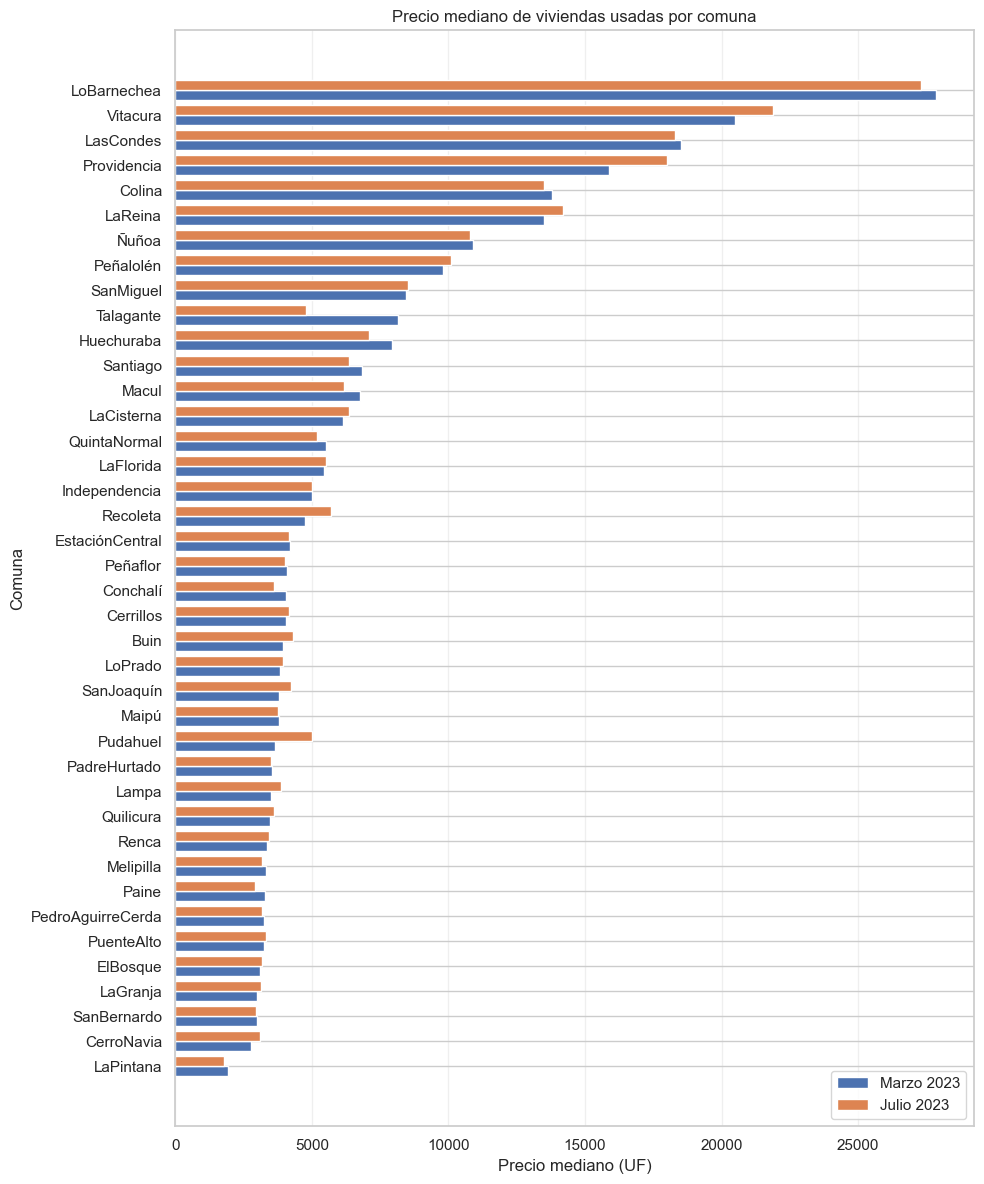

In [72]:
import matplotlib.pyplot as plt

df_marzo = resumen_precio_comuna["Precios Casas RM"].copy()
df_julio = resumen_precio_comuna["Propiedades Web Scrape"].copy()

comparacion_comunas = df_marzo[
    ["Comuna", "Precio_mediano_UF"]
].merge(
    df_julio[
        ["Comuna", "Precio_mediano_UF"]
    ],
    on="Comuna",
    suffixes=("_marzo", "_julio")
)

comparacion_comunas = comparacion_comunas.sort_values(
    "Precio_mediano_UF_marzo"
)

plt.figure(figsize=(10, 12))

y = range(len(comparacion_comunas))
ancho = 0.4

plt.barh(
    [i - ancho / 2 for i in y],
    comparacion_comunas["Precio_mediano_UF_marzo"],
    height=ancho,
    label="Marzo 2023"
)

plt.barh(
    [i + ancho / 2 for i in y],
    comparacion_comunas["Precio_mediano_UF_julio"],
    height=ancho,
    label="Julio 2023"
)

plt.yticks(
    y,
    comparacion_comunas["Comuna"]
)

plt.xlabel("Precio mediano (UF)")
plt.ylabel("Comuna")
plt.title("Precio mediano de viviendas usadas por comuna")
plt.legend()
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [73]:
for nombre, df in datasets_finales.items():
    print("=" * 60)
    print(nombre)
    print("=" * 60)

    superficie = df["Built Area"].dropna()

    print("\nPercentiles de superficie construida (m²):")

    display(
        superficie.quantile(
            [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
        ).to_frame("Built Area")
    )

    print("\nValores extremos:")

    display(
        superficie.sort_values(ascending=False).head(10).to_frame("Built Area")
    )

Precios Casas RM

Percentiles de superficie construida (m²):


,Built Area
0.01,42.0
0.05,54.0
0.25,85.0
0.50,128.0
0.75,200.0
0.95,450.0
0.99,840.3



Valores extremos:


,Built Area
7214,120000.0
784,60000.0
2248,18917.0
2773,17525.0
5038,15190.0
4688,10875.0
6290,7035.0
5294,6800.0
4553,5749.0
5976,5700.0


Propiedades Web Scrape

Percentiles de superficie construida (m²):


,Built Area
0.01,43.0
0.05,55.0
0.25,90.0
0.50,130.0
0.75,208.0
0.95,458.0
0.99,850.0



Valores extremos:


,Built Area
717,120000.0
2611,100350.0
2228,60000.0
1740,33000.0
3238,24546.0
7038,19000.0
7725,18917.0
7908,17525.0
3293,16151.0
755,12000.0


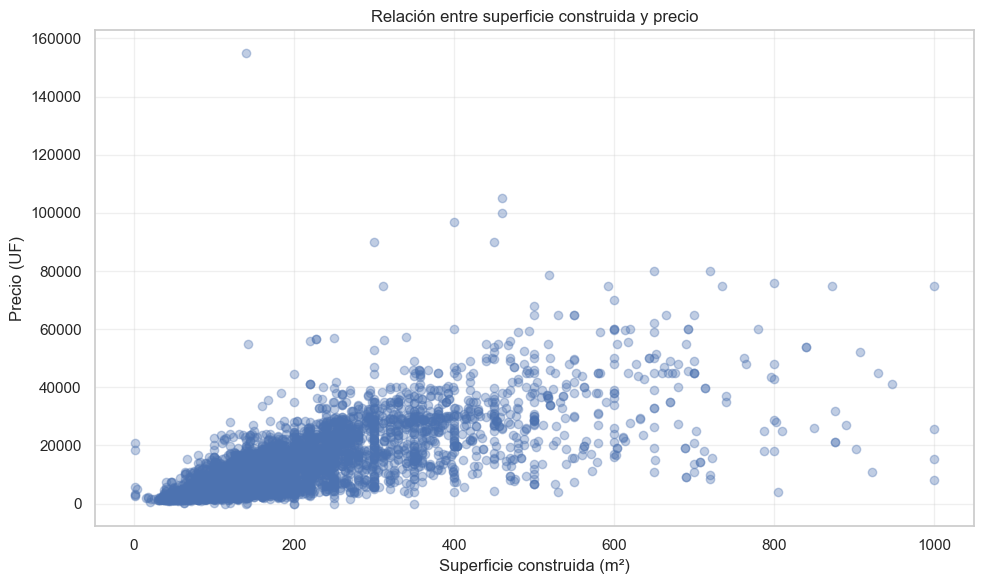

In [74]:
import matplotlib.pyplot as plt

df = datasets_finales["Precios Casas RM"]

df_grafico = df[
    df["Built Area"].notna() &
    (df["Built Area"] <= 1000)
].copy()

plt.figure(figsize=(10, 6))

plt.scatter(
    df_grafico["Built Area"],
    df_grafico["Price_UF"],
    alpha=0.35
)

plt.xlabel("Superficie construida (m²)")
plt.ylabel("Precio (UF)")
plt.title("Relación entre superficie construida y precio")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

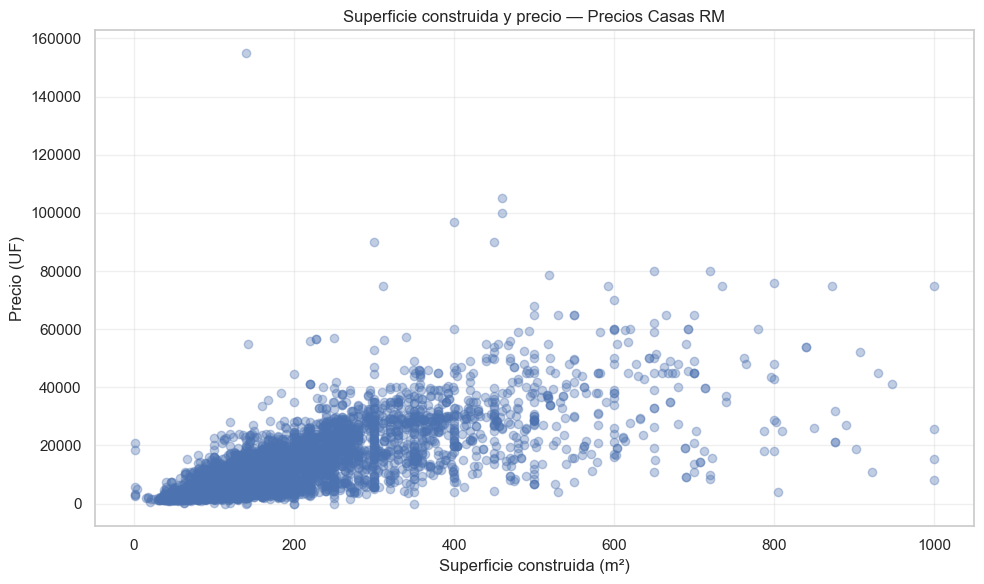

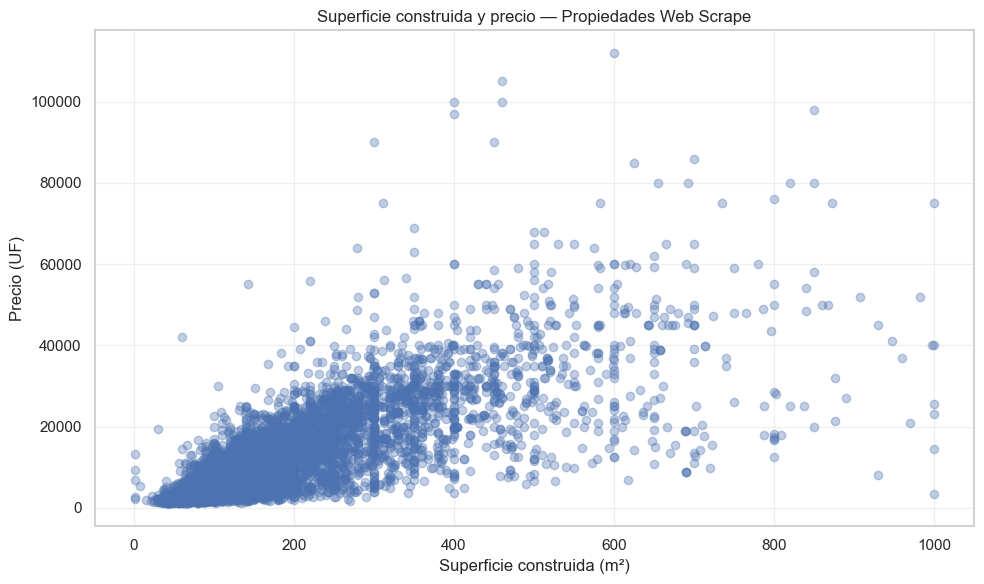

In [75]:
import matplotlib.pyplot as plt

for nombre, df in datasets_finales.items():

    df_grafico = df[
        df["Built Area"].notna() &
        (df["Built Area"] <= 1000)
    ].copy()

    plt.figure(figsize=(10, 6))

    plt.scatter(
        df_grafico["Built Area"],
        df_grafico["Price_UF"],
        alpha=0.35
    )

    plt.xlabel("Superficie construida (m²)")
    plt.ylabel("Precio (UF)")
    plt.title(f"Superficie construida y precio — {nombre}")
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

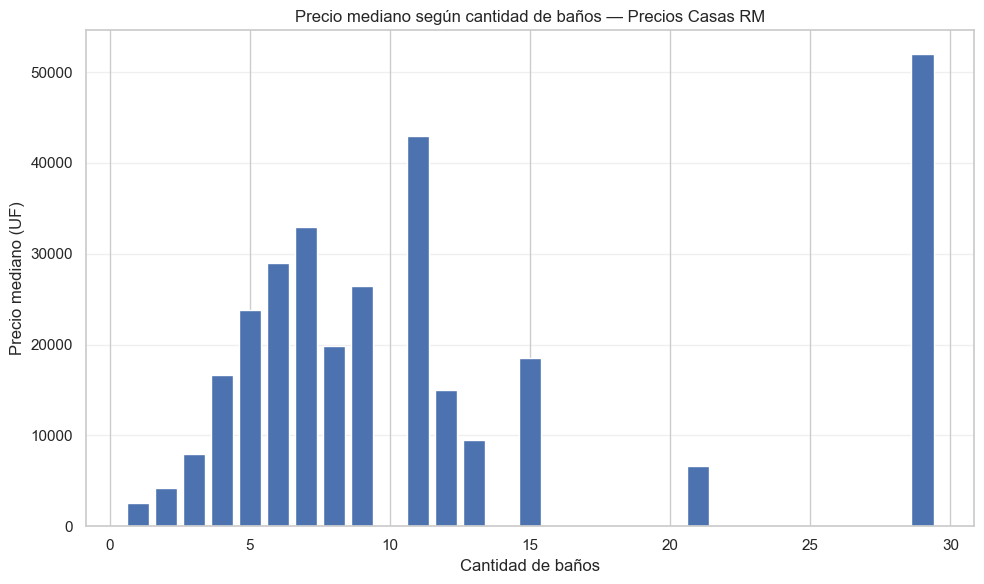

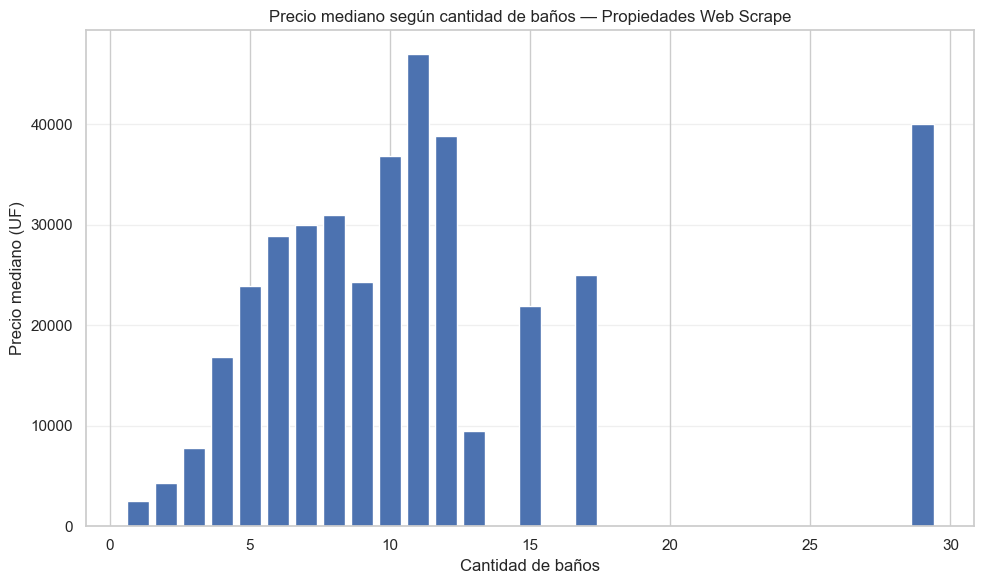

In [76]:
import matplotlib.pyplot as plt

for nombre, df in datasets_finales.items():

    df_grafico = df[
        df["Baths"].notna()
    ].copy()

    resumen_baños = (
        df_grafico
        .groupby("Baths")["Price_UF"]
        .median()
        .reset_index()
    )

    plt.figure(figsize=(10, 6))

    plt.bar(
        resumen_baños["Baths"],
        resumen_baños["Price_UF"]
    )

    plt.xlabel("Cantidad de baños")
    plt.ylabel("Precio mediano (UF)")
    plt.title(f"Precio mediano según cantidad de baños — {nombre}")
    plt.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

In [77]:
for nombre, df in datasets_finales.items():

    print("=" * 60)
    print(nombre)
    print("=" * 60)

    frecuencias_baños = (
        df["Baths"]
        .value_counts()
        .sort_index()
        .to_frame("Propiedades")
    )

    display(frecuencias_baños)

Precios Casas RM


,Propiedades
Baths,
1.0,1696
2.0,2280
3.0,1952
4.0,1021
5.0,459
6.0,153
7.0,75
8.0,23
9.0,7


Propiedades Web Scrape


,Propiedades
Baths,
1.0,1842
2.0,2513
3.0,2495
4.0,1308
5.0,617
6.0,208
7.0,81
8.0,27
9.0,12


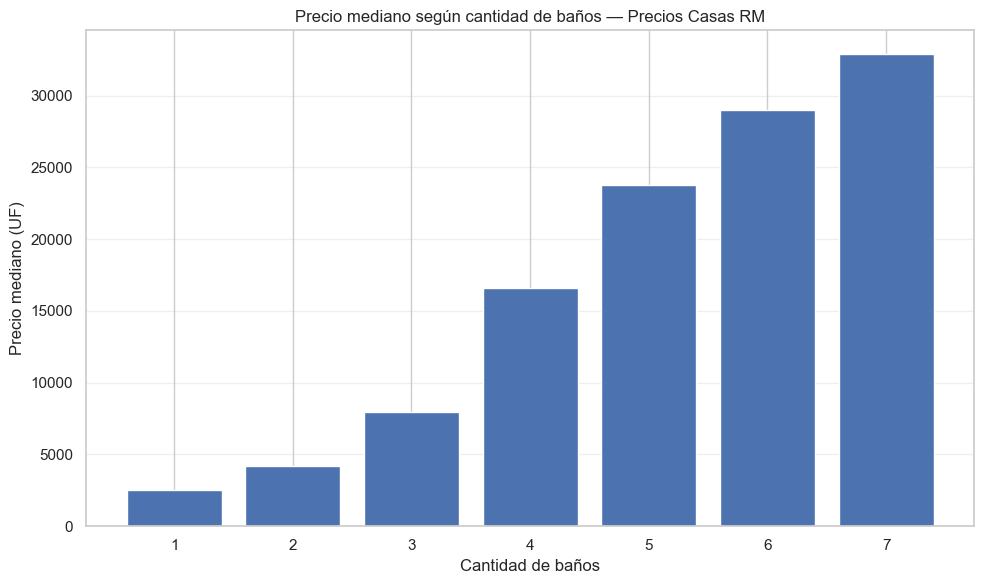

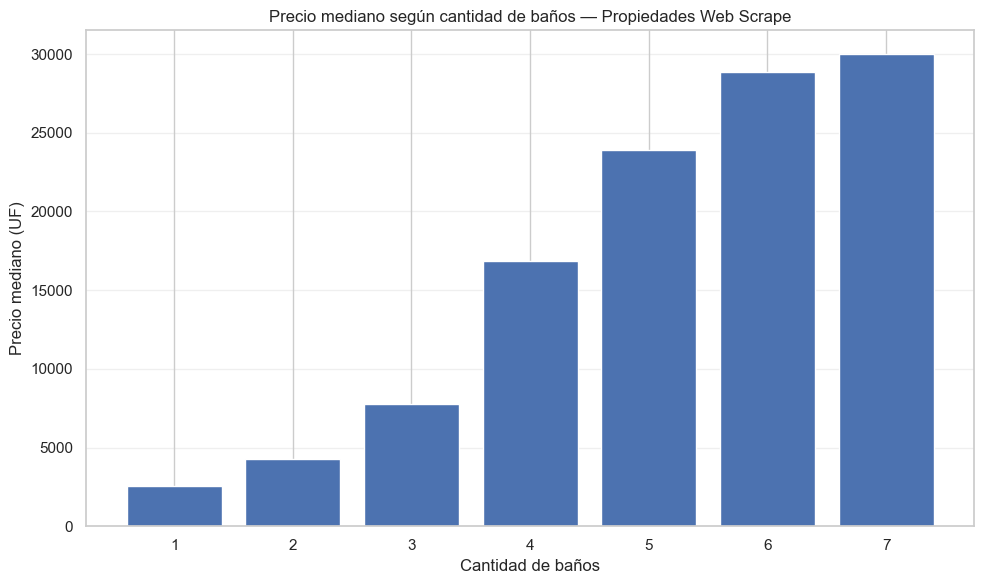

In [78]:
import matplotlib.pyplot as plt

for nombre, df in datasets_finales.items():

    df_grafico = df[
        df["Baths"].between(1, 7)
    ].copy()

    resumen_baños = (
        df_grafico
        .groupby("Baths")["Price_UF"]
        .median()
        .reset_index()
    )

    plt.figure(figsize=(10, 6))

    plt.bar(
        resumen_baños["Baths"],
        resumen_baños["Price_UF"]
    )

    plt.xlabel("Cantidad de baños")
    plt.ylabel("Precio mediano (UF)")
    plt.title(f"Precio mediano según cantidad de baños — {nombre}")
    plt.xticks(range(1, 8))
    plt.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

In [79]:
for nombre, df in datasets_finales.items():

    print("=" * 60)
    print(nombre)
    print("=" * 60)

    frecuencias_parking = (
        df["Parking"]
        .value_counts()
        .sort_index()
        .to_frame("Propiedades")
    )

    display(frecuencias_parking)

Precios Casas RM


,Propiedades
Parking,
1.0,1626
2.0,1896
3.0,823
4.0,443
5.0,212
6.0,184
7.0,47
8.0,84
9.0,9


Propiedades Web Scrape


,Propiedades
Parking,
1.0,1845
2.0,2184
3.0,1015
4.0,558
5.0,232
6.0,214
7.0,50
8.0,98
9.0,13


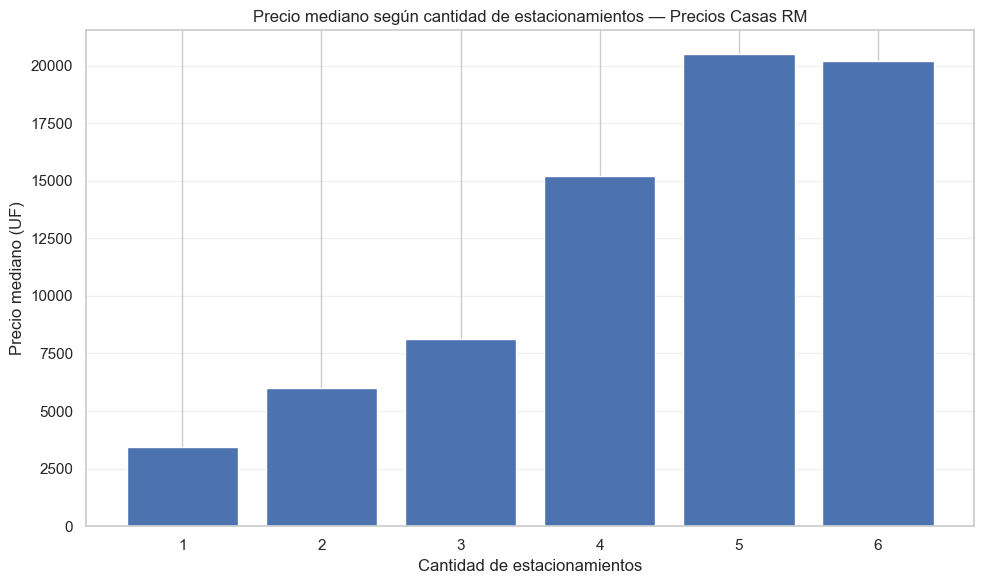

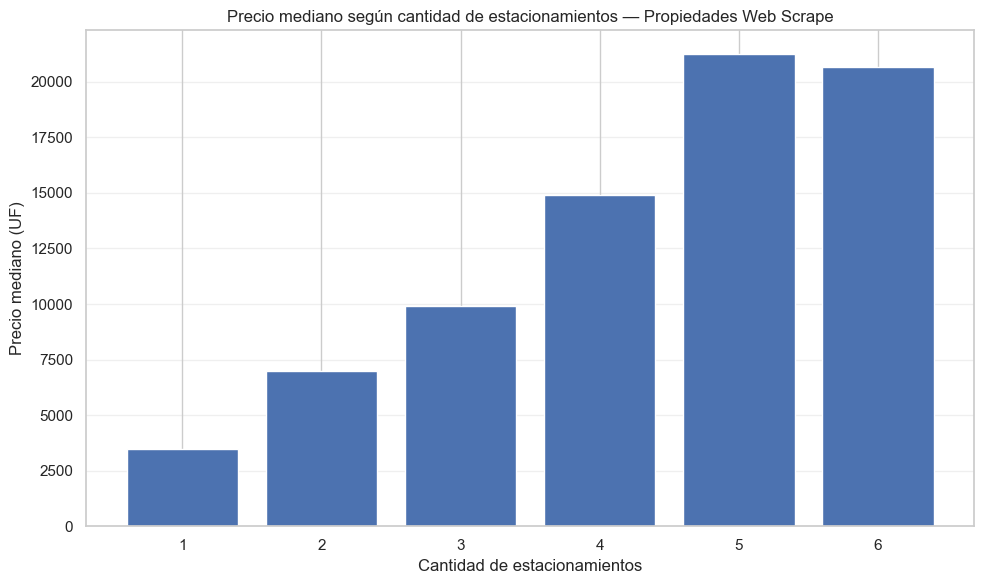

In [80]:
import matplotlib.pyplot as plt

for nombre, df in datasets_finales.items():

    df_grafico = df[
        df["Parking"].between(1, 6)
    ].copy()

    resumen_parking = (
        df_grafico
        .groupby("Parking")["Price_UF"]
        .median()
        .reset_index()
    )

    plt.figure(figsize=(10, 6))

    plt.bar(
        resumen_parking["Parking"],
        resumen_parking["Price_UF"]
    )

    plt.xlabel("Cantidad de estacionamientos")
    plt.ylabel("Precio mediano (UF)")
    plt.title(
        f"Precio mediano según cantidad de estacionamientos — {nombre}"
    )
    plt.xticks(range(1, 7))
    plt.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

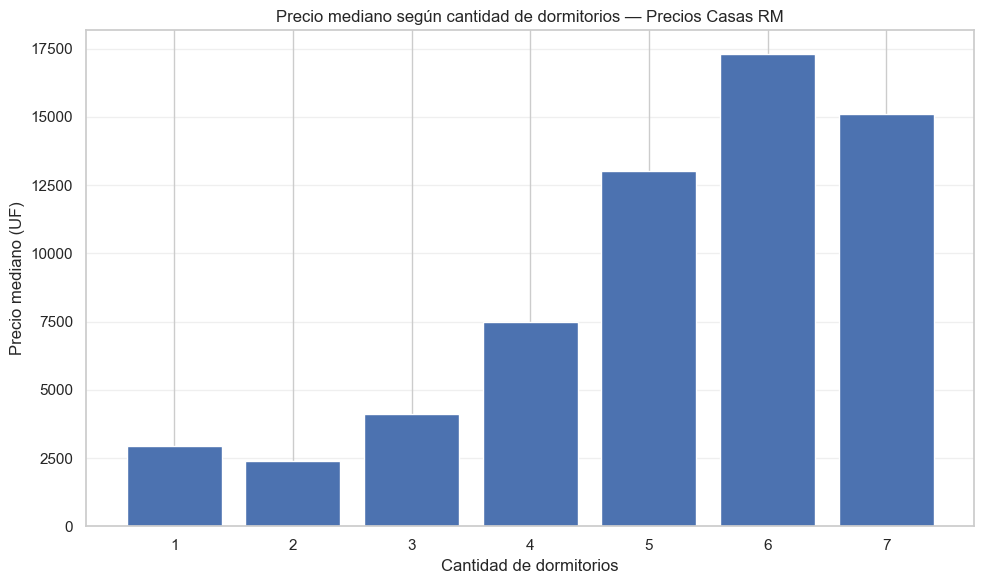

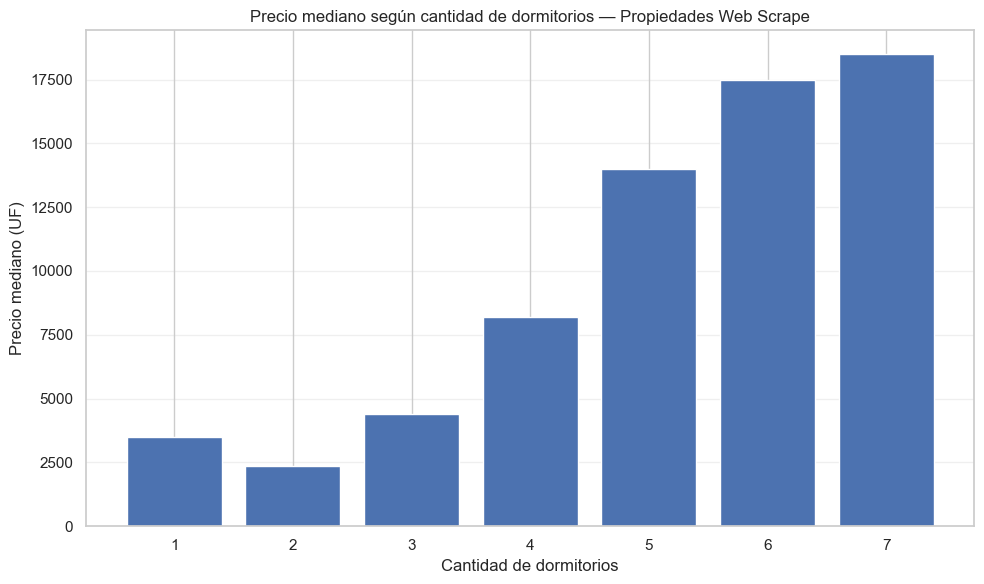

In [81]:
import matplotlib.pyplot as plt

for nombre, df in datasets_finales.items():

    df_grafico = df[
        df["Dorms"].between(1, 7)
    ].copy()

    resumen_dorms = (
        df_grafico
        .groupby("Dorms")["Price_UF"]
        .median()
        .reset_index()
    )

    plt.figure(figsize=(10, 6))

    plt.bar(
        resumen_dorms["Dorms"],
        resumen_dorms["Price_UF"]
    )

    plt.xlabel("Cantidad de dormitorios")
    plt.ylabel("Precio mediano (UF)")
    plt.title(
        f"Precio mediano según cantidad de dormitorios — {nombre}"
    )
    plt.xticks(range(1, 8))
    plt.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

In [82]:
import os

os.makedirs("../data/processed", exist_ok=True)

df_casas_final = datasets_finales["Precios Casas RM"]
df_propiedades_final = datasets_finales["Propiedades Web Scrape"]

df_casas_final.to_csv(
    "../data/processed/precios_casas_rm_limpio.csv",
    index=False
)

df_propiedades_final.to_csv(
    "../data/processed/propiedades_web_scrape_limpio.csv",
    index=False
)

print("Archivos procesados guardados correctamente.")
print()
print("Precios Casas RM:", df_casas_final.shape)
print("Propiedades Web Scrape:", df_propiedades_final.shape)

Archivos procesados guardados correctamente.

Precios Casas RM: (7744, 12)
Propiedades Web Scrape: (9275, 12)
